# DINOv2 + FPN Dual-Task: Segmentation + Classification
## Breast Ultrasound (BUSI) Dataset — Ablation Study: Baseline FPN (Phase-01 & Phase-02)

**Architecture change:** The original lightweight single-layer decoder is replaced with a
**Feature Pyramid Network (FPN)** that taps DINOv2 intermediate hidden states at four depth
levels (blocks 3 · 6 · 9 · 12), builds a top-down lateral-connection pyramid, merges all
levels, and progressively upsamples to the target resolution.

| Component | Original notebook | This notebook |
|-----------|------------------|---------------|
| Backbone | DINOv2 ViT-B/14 | DINOv2 ViT-B/14 (unchanged) |
| Seg decoder | Single-layer Linear → 4×ConvTranspose | **FPN** (4-stage pyramid + top-down pathway) |
| Cls head | LayerNorm→Linear→GELU→Dropout→Linear | Identical |
| Training | Basic AMP-less loop | **Mixed-precision (AMP)** |
| Stopping | Fixed 50 epochs | **Early stopping** (patience=10) |
| Phases | with/without aug | **Phase-01**: no aug · **Phase-02**: strong aug |

**All metrics, evaluation protocols, visualisations, and reporting structures are kept
identical to the original notebook for fair ablation comparison.**


In [2]:
# Run once — comment out after first run
# !pip install transformers timm albumentations segmentation-models-pytorch tqdm


In [3]:
import os, re, time, json, random, warnings
from typing import Optional
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_recall_fscore_support)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from transformers import Dinov2Model

from tqdm import tqdm

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ── Master config ──────────────────────────────────────────────────────────────
CFG = {
    # Dataset
    "data_root": r"C:\Users\ASHAH\OneDrive - northsouth.edu\Desktop\Breast_Lesion_Segmentation\breast_ultrasound\combined_breast_ultrasound_dataset",

    # Image — DINOv2 ViT-B/14: patch_size=14;  322 = 23 × 14
    "img_size":    322,
    "patch_size":  14,

    # Training
    "batch_size":  8,
    "epochs":      50,
    "lr":          1e-4,        # heads / decoder
    "encoder_lr":  1e-5,        # backbone (10× smaller — differential LR)
    "num_workers": 0,
    "weight_decay": 1e-4,
    "warmup_epochs": 5,         # freeze backbone for first N epochs

    # Early stopping
    "patience":    10,          # epochs without Dice improvement before stopping
    "min_delta":   1e-4,

    # Model
    "dino_model":  "facebook/dinov2-base",
    "num_classes": 3,           # benign / malignant / normal
    "fpn_dim":     256,         # unified channel width in the FPN pyramid

    # Loss — Phase-01 / Phase-02 (Dice + BCE)
    "cls_weight":  0.4,         # total = seg_loss + cls_weight * cls_loss
    "threshold":   0.5,

    # Loss — Phase-03 (Focal-Tversky)
    "ft_alpha":    0.7,          # FP penalty  (α < β → recall-oriented)
    "ft_beta":     0.3,          # FN penalty  (β < α → precision-oriented)
    "ft_gamma":    0.75,         # focal exponent — sharpens hard examples

    # Loss — Phase-04 (Focal-Tversky + Supervised Contrastive)
    "supcon_weight":   0.1,      # weight for SupCon loss term
    "supcon_temp":     0.07,     # contrastive softmax temperature
    "supcon_proj_dim": 128,      # projection head output dimension

    # Phase-05 (Test-Time Augmentation)
    "tta_n_aug":   4,            # variants: orig · h-flip · v-flip · hv-flip

    # Reproducibility
    "seed": 42,
}

LABEL2IDX = {"benign": 0, "malignant": 1, "normal": 2}
IDX2LABEL  = {v: k for k, v in LABEL2IDX.items()}
CLASS_NAMES = ["benign", "malignant", "normal"]

PATCH_GRID  = CFG["img_size"] // CFG["patch_size"]   # 23
NUM_PATCHES = PATCH_GRID ** 2                          # 529

print(f"Patch grid : {PATCH_GRID}x{PATCH_GRID} = {NUM_PATCHES} patches")


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Patch grid : 23x23 = 529 patches


In [4]:
def set_seed(seed: int = 42):
    """Fix all relevant random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"]       = str(seed)

set_seed(CFG["seed"])
print(f"Seeds fixed — seed={CFG['seed']}")


Seeds fixed — seed=42


In [5]:
DATASET_ROOT = Path(CFG["data_root"])

rows = []
for cls_name in ["benign", "malignant", "normal"]:
    cls_dir  = DATASET_ROOT / cls_name
    img_dir  = cls_dir / "images"
    mask_dir = cls_dir / "masks"

    masks = {
        re.sub(r"_mask$", "", p.stem): str(p)
        for p in mask_dir.glob("*.png")
    }

    for img_path in sorted(img_dir.glob("*.png")):
        key = img_path.stem
        rows.append({
            "image_path": str(img_path),
            "mask_path":  masks.get(key, None),
            "label":      cls_name,
            "label_idx":  LABEL2IDX[cls_name],
        })

df = pd.DataFrame(rows)
print(df["label"].value_counts())
print("Total:", len(df))
print("With mask:", df["mask_path"].notna().sum())


label
normal       729
benign       477
malignant    261
Name: count, dtype: int64
Total: 1467
With mask: 1467


In [6]:
set_seed(CFG["seed"])   # ensure reproducible split

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=CFG["seed"], stratify=df["label"]
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=CFG["seed"], stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  |  Valid: {len(valid_df)}  |  Test: {len(test_df)}")


Train: 1026  |  Valid: 220  |  Test: 221


In [7]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class BUSIDinoDataset(Dataset):
    """
    BUSI dataset loader — identical to original notebook.
    Converts grayscale images to 3-channel RGB by repeating the channel,
    then normalises with ImageNet mean/std (required by DINOv2 weights).

    Returns
    -------
    image      : FloatTensor [3, H, W]   (ImageNet-normalised)
    mask       : FloatTensor [1, H, W]   (binary 0/1)
    label      : str
    label_idx  : LongTensor scalar
    """

    def __init__(self, df, transforms=None):
        self.df         = df.reset_index(drop=True)
        self.transforms = transforms
        self.H = CFG["img_size"]
        self.W = CFG["img_size"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(f"Image not found: {row['image_path']}")

        mask_path = row["mask_path"]
        if mask_path and Path(mask_path).exists():
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype(np.float32)
        else:
            mask = np.zeros(image.shape, dtype=np.float32)

        image = cv2.resize(image, (self.W, self.H), interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask,  (self.W, self.H), interpolation=cv2.INTER_NEAREST)

        if self.transforms is not None:
            out   = self.transforms(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"]

        # Grayscale -> 3-channel
        image = image.astype(np.float32) / 255.0
        image = np.stack([image, image, image], axis=-1)        # [H, W, 3]
        image = (image - IMAGENET_MEAN) / IMAGENET_STD          # ImageNet norm
        image = np.transpose(image, (2, 0, 1))                  # [3, H, W]
        mask  = np.expand_dims(mask.astype(np.float32), 0)      # [1, H, W]

        return {
            "image":     torch.tensor(image, dtype=torch.float32),
            "mask":      torch.tensor(mask,  dtype=torch.float32),
            "label":     row["label"],
            "label_idx": torch.tensor(row["label_idx"], dtype=torch.long),
        }


# Quick sanity check
_tmp = BUSIDinoDataset(train_df)
_s   = _tmp[0]
print("image shape:", _s["image"].shape)   # [3, 322, 322]
print("mask  shape:", _s["mask"].shape)    # [1, 322, 322]
print("label:",       _s["label"])
del _tmp, _s


image shape: torch.Size([3, 322, 322])
mask  shape: torch.Size([1, 322, 322])
label: malignant


In [8]:
# Phase-01: no augmentation (resize only)
no_aug_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])

# Phase-02: strong synchronized augmentation (applied to image + mask together)
strong_aug_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.10,
        rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.5
    ),
    A.ElasticTransform(p=0.3),
    A.GridDistortion(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.2),
    A.GaussNoise(p=0.2),
])

# Validation / test always uses no-aug (resize only)
val_tfms = A.Compose([A.Resize(CFG["img_size"], CFG["img_size"])])

print("Transforms defined:")
print("  no_aug_tfms    — resize only (Phase-01 train / all val+test)")
print("  strong_aug_tfms — 9-transform strong aug (Phase-02 train)")


Transforms defined:
  no_aug_tfms    — resize only (Phase-01 train / all val+test)
  strong_aug_tfms — 9-transform strong aug (Phase-02 train)


## FPN Decoder Architecture

```
DINOv2 backbone  (output_hidden_states=True)
       │
       ├── hidden_states[3]   [B, 530, 768]  ─── lateral_conv ──► [B, 256, 23, 23]  ◄─ P1 (shallow)
       ├── hidden_states[6]   [B, 530, 768]  ─── lateral_conv ──► [B, 256, 23, 23]  ◄─ P2
       ├── hidden_states[9]   [B, 530, 768]  ─── lateral_conv ──► [B, 256, 23, 23]  ◄─ P3
       └── hidden_states[12]  [B, 530, 768]  ─── lateral_conv ──► [B, 256, 23, 23]  ◄─ P4 (deep)
                                                                            │
                                              Top-down pathway (upsample + add + 3×3 conv)
                                                                            │
                                              Concat all 4 levels → [B, 1024, 23, 23]
                                                                            │
                                              merge_conv 1×1 → [B, 256, 23, 23]
                                                                            │
                                         Progressive ConvTranspose2d upsample:
                                              23 → 46 → 92 → 184 → 368
                                                                            │
                                         Bilinear interpolate → [B, 16, 322, 322]
                                                                            │
                                         seg_head Conv2d(1×1) → [B, 1, 322, 322]
```


In [9]:
class DINOv2FPNDecoder(nn.Module):
    """
    Feature Pyramid Network decoder for DINOv2.

    Replaces the original single-depth SegDecoder with a proper FPN that:
      1. Taps 4 ViT intermediate hidden states (blocks 3, 6, 9, 12)
      2. Projects each to a unified channel dimension via Linear + LayerNorm
      3. Reshapes tokens to spatial maps [B, fpn_dim, grid, grid]
      4. Builds a top-down pathway (upsample + residual add + 3×3 smooth conv)
      5. Concatenates all pyramid levels, merges with a 1×1 conv
      6. Progressively upsamples via 4 ConvTranspose2d blocks
      7. Bilinear-resizes to exact img_size; 1×1 seg_head → 1 logit channel

    EXTRACT_LAYERS: indices into outputs.hidden_states (0 = embedding output,
    1-12 = after each ViT block). Tapping {3, 6, 9, 12} gives quarter-depth features.
    """

    EXTRACT_LAYERS = (3, 6, 9, 12)   # indices into hidden_states tuple

    def __init__(
        self,
        embed_dim:  int = 768,
        fpn_dim:    int = 256,
        patch_grid: int = 23,
        img_size:   int = 322,
    ):
        super().__init__()
        self.patch_grid = patch_grid
        self.img_size   = img_size
        self.n_stages   = len(self.EXTRACT_LAYERS)

        # Lateral projections: token-space Linear + LayerNorm per stage
        self.laterals = nn.ModuleList([
            nn.Sequential(nn.Linear(embed_dim, fpn_dim), nn.LayerNorm(fpn_dim))
            for _ in self.EXTRACT_LAYERS
        ])

        # FPN output convolutions: 3×3 smooth after top-down addition
        self.fpn_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(fpn_dim, fpn_dim, 3, padding=1),
                nn.BatchNorm2d(fpn_dim),
                nn.ReLU(inplace=True),
            )
            for _ in self.EXTRACT_LAYERS
        ])

        # Merge all 4 pyramid levels (cat → 1×1 conv)
        self.merge = nn.Sequential(
            nn.Conv2d(self.n_stages * fpn_dim, fpn_dim, 1),
            nn.BatchNorm2d(fpn_dim),
            nn.ReLU(inplace=True),
        )

        # Progressive upsample: 23 → 46 → 92 → 184 → 368 → bilinear(322)
        self.up1 = self._up_block(fpn_dim, 128)
        self.up2 = self._up_block(128,     64)
        self.up3 = self._up_block(64,      32)
        self.up4 = self._up_block(32,      16)

        self.seg_head = nn.Conv2d(16, 1, 1)

    @staticmethod
    def _up_block(in_ch: int, out_ch: int) -> nn.Sequential:
        """2× ConvTranspose + BN + ReLU + refinement Conv + BN + ReLU."""
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, all_hidden_states, img_size: int):
        """
        Parameters
        ----------
        all_hidden_states : tuple[Tensor]
            One [B, 1+N, D] tensor per ViT layer from outputs.hidden_states.
        img_size : int
            Target spatial resolution for the output mask.

        Returns
        -------
        Tensor  [B, 1, img_size, img_size]  — raw segmentation logits.
        """
        B = all_hidden_states[0].shape[0]
        g = self.patch_grid                             # 23

        # ── Step 1: lateral projections → spatial feature maps ───────────────
        stage_maps = []
        for i, layer_idx in enumerate(self.EXTRACT_LAYERS):
            tokens = all_hidden_states[layer_idx][:, 1:, :]  # drop CLS → [B, N, D]
            proj   = self.laterals[i](tokens)                 # [B, N, fpn_dim]
            feat   = proj.transpose(1, 2).reshape(B, -1, g, g)  # [B, fpn_dim, g, g]
            stage_maps.append(feat)

        # ── Step 2: top-down FPN pathway ─────────────────────────────────────
        fpn_maps = [None] * self.n_stages
        fpn_maps[-1] = self.fpn_convs[-1](stage_maps[-1])    # deepest level (no addition)

        for i in range(self.n_stages - 2, -1, -1):
            up = F.interpolate(
                fpn_maps[i + 1],
                size=stage_maps[i].shape[-2:],
                mode="bilinear", align_corners=False,
            )
            fpn_maps[i] = self.fpn_convs[i](stage_maps[i] + up)  # lateral + top-down

        # ── Step 3: align all levels → concatenate → merge ───────────────────
        base_size = fpn_maps[0].shape[-2:]
        aligned   = [
            F.interpolate(f, size=base_size, mode="bilinear", align_corners=False)
            for f in fpn_maps
        ]
        x = self.merge(torch.cat(aligned, dim=1))              # [B, fpn_dim, g, g]

        # ── Step 4: progressive upsample ─────────────────────────────────────
        x = self.up1(x)   # [B, 128, 46, 46]
        x = self.up2(x)   # [B,  64, 92, 92]
        x = self.up3(x)   # [B,  32,184,184]
        x = self.up4(x)   # [B,  16,368,368]

        x = F.interpolate(x, size=(img_size, img_size),
                          mode="bilinear", align_corners=False)
        return self.seg_head(x)                                # [B, 1, H, W]


In [10]:
class DINOv2FPNDualTask(nn.Module):
    """
    DINOv2 ViT-B/14 backbone with FPN segmentation decoder and CLS classification head.

    Key differences from original DINODualTaskModel:
      • backbone is called with output_hidden_states=True (needed for FPN)
      • seg_decoder is DINOv2FPNDecoder (FPN) instead of SegDecoder (linear)
      • cls_head is identical to the original notebook
    """

    def __init__(
        self,
        dino_model_name: str  = "facebook/dinov2-base",
        num_classes:     int  = 3,
        patch_grid:      int  = 23,
        img_size:        int  = 322,
        fpn_dim:         int  = 256,
        freeze_backbone: bool = False,
    ):
        super().__init__()
        self.img_size = img_size

        # Backbone
        self.backbone = Dinov2Model.from_pretrained(dino_model_name)
        embed_dim     = self.backbone.config.hidden_size    # 768 for dinov2-base

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # Classification head — identical to original notebook
        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

        # FPN segmentation decoder (replaces SegDecoder)
        self.seg_decoder = DINOv2FPNDecoder(
            embed_dim=embed_dim,
            fpn_dim=fpn_dim,
            patch_grid=patch_grid,
            img_size=img_size,
        )

    def forward(self, pixel_values, return_features: bool = False):
        """
        Parameters
        ----------
        pixel_values    : Tensor [B, 3, H, W]
        return_features : bool
            If True, also returns the raw CLS token [B, embed_dim] before the
            classification head — required by Phase-04 SupCon projection head.

        Returns
        -------
        seg_logits : Tensor [B, 1, H, W]       raw logits (no sigmoid)
        cls_logits : Tensor [B, num_classes]
        cls_token  : Tensor [B, embed_dim]      only when return_features=True
        """
        outputs = self.backbone(
            pixel_values=pixel_values,
            output_hidden_states=True,          # ← required for multi-stage FPN
        )
        # last_hidden_state  : [B, 1+N, D]   (CLS + patch tokens, final layer)
        # hidden_states      : tuple of [B, 1+N, D], one per layer
        cls_token     = outputs.last_hidden_state[:, 0, :]
        hidden_states = outputs.hidden_states       # tuple length = num_layers + 1

        seg_logits = self.seg_decoder(hidden_states, self.img_size)
        cls_logits = self.cls_head(cls_token)

        if return_features:
            return seg_logits, cls_logits, cls_token   # Phase-04 SupCon path
        return seg_logits, cls_logits

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


# ── Shape sanity check ────────────────────────────────────────────────────────
print("Loading DINOv2 backbone (first run will download ~330 MB)...")
_model = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

_x = torch.randn(2, 3, CFG["img_size"], CFG["img_size"]).to(device)
with torch.no_grad():
    _seg, _cls = _model(_x)

print(f"Seg logits : {_seg.shape}  (expected [2, 1, {CFG['img_size']}, {CFG['img_size']}])")
print(f"Cls logits : {_cls.shape}  (expected [2, {CFG['num_classes']}])")

n_total = sum(p.numel() for p in _model.parameters()) / 1e6
n_train = sum(p.numel() for p in _model.parameters() if p.requires_grad) / 1e6
print(f"Total params : {n_total:.1f} M")
print(f"Trainable    : {n_train:.1f} M")
del _x, _seg, _cls, _model


Loading DINOv2 backbone (first run will download ~330 MB)...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Seg logits : torch.Size([2, 1, 322, 322])  (expected [2, 1, 322, 322])
Cls logits : torch.Size([2, 3])  (expected [2, 3])
Total params : 90.8 M
Trainable    : 90.8 M


In [11]:
# ── Loss functions ────────────────────────────────────────────────────────────
dice_loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss_fn  = nn.BCEWithLogitsLoss()
ce_loss_fn   = nn.CrossEntropyLoss()


def compute_combined_loss(seg_logits, cls_logits, masks, labels):
    """
    Dual-task combined loss (identical to original notebook).
      seg_loss  = DiceLoss + BCEWithLogitsLoss
      cls_loss  = CrossEntropyLoss
      total     = seg_loss + cls_weight * cls_loss
    """
    seg_loss = dice_loss_fn(seg_logits, masks) + bce_loss_fn(seg_logits, masks)
    cls_loss = ce_loss_fn(cls_logits, labels)
    total    = seg_loss + CFG["cls_weight"] * cls_loss
    return total, seg_loss, cls_loss


# ── Segmentation metrics ───────────────────────────────────────────────────────
def dice_score(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()


def iou_score(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()


def seg_precision_recall(seg_logits, masks, threshold=0.5, eps=1e-7):
    """Pixel-level binary precision / recall / F1, averaged over the batch."""
    preds = (torch.sigmoid(seg_logits) > threshold).float()
    tp = (preds * masks).sum(dim=(1, 2, 3))
    fp = (preds * (1 - masks)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * masks).sum(dim=(1, 2, 3))
    prec = (tp / (tp + fp + eps)).mean().item()
    rec  = (tp / (tp + fn + eps)).mean().item()
    f1   = (2 * tp / (2 * tp + fp + fn + eps)).mean().item()
    return prec, rec, f1


# ── Classification metrics ─────────────────────────────────────────────────────
def cls_accuracy(cls_logits, labels):
    return (cls_logits.argmax(dim=1) == labels).float().mean().item()


def cls_precision_recall_f1(cls_logits, labels):
    """Macro-averaged precision / recall / F1 for the 3-class head."""
    preds = cls_logits.argmax(dim=1).cpu().numpy()
    labs  = labels.cpu().numpy()
    p, r, f1, _ = precision_recall_fscore_support(
        labs, preds, average="macro", zero_division=0)
    return float(p), float(r), float(f1), preds, labs


print("Loss functions and metric helpers defined.")

# ── Focal-Tversky Loss ─────────────────────────────────────────────────────────
class FocalTverskyLoss(nn.Module):
    """
    Focal-Tversky Loss for binary segmentation (from_logits=True).

    Tversky Index (TI):
        TI = TP / (TP + α·FP + β·FN + ε)

    Focal-Tversky Loss (FTL):
        FTL = (1 - TI)^γ

    Medical imaging rationale:
      • α=0.7, β=0.3 → penalises false negatives (missed lesions) more
        than false positives — critical for breast ultrasound where
        missing a malignant lesion is far costlier than a false alarm
      • γ=0.75 → sub-unity focal exponent sharpens focus on hard,
        poorly-segmented examples while down-weighting easy cases
    """

    def __init__(self,
                 alpha:  float = 0.7,
                 beta:   float = 0.3,
                 gamma:  float = 0.75,
                 eps:    float = 1e-7):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.eps   = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        logits  : [B, 1, H, W]  raw (pre-sigmoid) segmentation output
        targets : [B, 1, H, W]  binary ground-truth mask (0/1 float)
        """
        probs = torch.sigmoid(logits)

        # Flatten spatial dims
        probs_f   = probs.view(probs.shape[0], -1)     # [B, H*W]
        targets_f = targets.view(targets.shape[0], -1)  # [B, H*W]

        tp = (probs_f * targets_f).sum(dim=1)
        fp = (probs_f * (1 - targets_f)).sum(dim=1)
        fn = ((1 - probs_f) * targets_f).sum(dim=1)

        tversky_index = (tp + self.eps) / (tp + self.alpha * fp + self.beta * fn + self.eps)
        focal_tversky = (1 - tversky_index) ** self.gamma
        return focal_tversky.mean()


# Instantiate with CFG values (used by Phase-03 only)
focal_tversky_loss_fn = FocalTverskyLoss(
    alpha=CFG["ft_alpha"],
    beta=CFG["ft_beta"],
    gamma=CFG["ft_gamma"],
)


def compute_combined_loss_ft(seg_logits, cls_logits, masks, labels):
    """
    Phase-03 dual-task loss with Focal-Tversky segmentation loss.

      seg_loss = FocalTverskyLoss  (replaces Dice + BCE)
      cls_loss = CrossEntropyLoss  (unchanged)
      total    = seg_loss + cls_weight * cls_loss

    Keeps the same return signature as compute_combined_loss so every
    downstream metric accumulation cell works without modification.
    """
    seg_loss = focal_tversky_loss_fn(seg_logits, masks)
    cls_loss = ce_loss_fn(cls_logits, labels)
    total    = seg_loss + CFG["cls_weight"] * cls_loss
    return total, seg_loss, cls_loss


print("FocalTverskyLoss and compute_combined_loss_ft defined.")

# ── Supervised Contrastive Loss (Phase-04) ────────────────────────────────────
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss — Khosla et al., NeurIPS 2020.

    Pulls together L2-normalised embeddings of the same class while
    pushing apart embeddings of different classes, giving the CLS token
    a tighter, more discriminative embedding space for classification.

    Formula (per anchor i):
        L_i = -1/|P(i)| · Σ_{p∈P(i)} log [exp(z_i·z_p / τ) / Σ_{a≠i} exp(z_i·z_a / τ)]

    where P(i) = set of same-class positives in the batch (excluding self).
    """

    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        features : [B, D]  L2-normalised projection embeddings
        labels   : [B]     integer class labels
        """
        device = features.device
        B = features.shape[0]

        # Pairwise cosine similarities (already normalised → dot product)
        sim = torch.matmul(features, features.T) / self.temperature   # [B, B]

        # Positive mask: same class, exclude self-pairs
        labels_col  = labels.view(-1, 1)
        pos_mask    = (labels_col == labels_col.T).float()             # [B, B]
        self_mask   = torch.eye(B, device=device)
        pos_mask    = pos_mask - self_mask                             # zero diagonal

        # Numerical stability: subtract row-max
        sim_max, _ = sim.max(dim=1, keepdim=True)
        sim        = sim - sim_max.detach()

        exp_sim = torch.exp(sim)
        # Denominator: all pairs except self
        denom   = (exp_sim * (1 - self_mask)).sum(dim=1, keepdim=True)

        log_prob  = sim - torch.log(denom + 1e-8)
        pos_count = pos_mask.sum(dim=1)

        # Mean over positive pairs; samples with no positives contribute 0
        loss = -(pos_mask * log_prob).sum(dim=1) / (pos_count + 1e-8)
        return loss.mean()


class SupConProjectionHead(nn.Module):
    """
    MLP projection head: maps raw CLS token [B, 768] → L2-normalised
    embedding [B, supcon_proj_dim] for SupCon loss computation.

    Architecture: Linear → ReLU → Linear → L2-norm
    Kept separate from the model so it is excluded from Phase-01/02/03
    training loops without any code change.
    """

    def __init__(self,
                 in_dim:     int = 768,
                 hidden_dim: int = 256,
                 out_dim:    int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.net(x), dim=1)   # L2-normalise


# Instantiate — used only in Phase-04 training; defined here for cell-order clarity
supcon_loss_fn_instance = SupConLoss(temperature=CFG["supcon_temp"])


def compute_combined_loss_sc(seg_logits, cls_logits, masks, labels,
                              proj_features=None):
    """
    Phase-04 dual-task loss: Focal-Tversky + CE + Supervised Contrastive.

      seg_loss    = FocalTverskyLoss          (same as Phase-03)
      cls_loss    = CrossEntropyLoss          (unchanged)
      supcon_loss = SupConLoss on proj_feats  (new in Phase-04)
      total       = seg_loss
                  + cls_weight   * cls_loss
                  + supcon_weight * supcon_loss

    Same 3-tuple return signature as all other loss functions — SupCon is
    absorbed into `total` so downstream metric accumulation is unchanged.
    """
    seg_loss = focal_tversky_loss_fn(seg_logits, masks)
    cls_loss = ce_loss_fn(cls_logits, labels)
    if proj_features is not None:
        sc_loss = supcon_loss_fn_instance(proj_features, labels)
    else:
        sc_loss = torch.tensor(0.0, device=seg_logits.device)
    total = (seg_loss
             + CFG["cls_weight"]    * cls_loss
             + CFG["supcon_weight"] * sc_loss)
    return total, seg_loss, cls_loss


print("SupConLoss, SupConProjectionHead, compute_combined_loss_sc defined.")


Loss functions and metric helpers defined.
FocalTverskyLoss and compute_combined_loss_ft defined.
SupConLoss, SupConProjectionHead, compute_combined_loss_sc defined.


In [12]:
def make_loaders(train_tfms, val_tfms):
    """Build train / valid / test DataLoaders with a fresh seed worker."""

    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    g = torch.Generator()
    g.manual_seed(CFG["seed"])

    train_ds = BUSIDinoDataset(train_df, transforms=train_tfms)
    valid_ds = BUSIDinoDataset(valid_df, transforms=val_tfms)
    test_ds  = BUSIDinoDataset(test_df,  transforms=val_tfms)

    train_loader = DataLoader(
        train_ds, batch_size=CFG["batch_size"], shuffle=True,
        num_workers=CFG["num_workers"], pin_memory=True,
        worker_init_fn=seed_worker, generator=g,
    )
    valid_loader = DataLoader(
        valid_ds, batch_size=CFG["batch_size"], shuffle=False,
        num_workers=CFG["num_workers"], pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=CFG["batch_size"], shuffle=False,
        num_workers=0, pin_memory=True,
    )

    print(f"train={len(train_ds)}  valid={len(valid_ds)}  test={len(test_ds)}")
    return train_loader, valid_loader, test_loader, valid_ds, test_ds


In [13]:
def build_optimizer(model, extra_modules=None):
    """
    Differential learning rates:
      backbone                → encoder_lr  (10× smaller)
      heads / FPN / extras    → lr

    Parameters
    ----------
    extra_modules : list of nn.Module, optional
        Additional modules (e.g. SupConProjectionHead) whose parameters are
        added to the head param group. Phase-01/02/03 pass nothing → unchanged.
    """
    backbone_params = list(model.backbone.parameters())
    head_params     = (list(model.cls_head.parameters()) +
                       list(model.seg_decoder.parameters()))
    if extra_modules:
        for m in extra_modules:
            head_params += list(m.parameters())

    optimizer = AdamW([
        {"params": backbone_params, "lr": CFG["encoder_lr"],
         "weight_decay": CFG["weight_decay"]},
        {"params": head_params,     "lr": CFG["lr"],
         "weight_decay": CFG["weight_decay"]},
    ])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-7)
    return optimizer, scheduler


In [14]:
class EarlyStopping:
    """
    Monitors a metric and signals when it stops improving.
    Caches the best model weights in CPU memory for seamless restoration.

    Parameters
    ----------
    patience  : int   — epochs to wait after last improvement
    min_delta : float — minimum change to count as improvement
    mode      : 'max' or 'min'
    """

    def __init__(self, patience: int = 10, min_delta: float = 1e-4,
                 mode: str = "max"):
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.counter    = 0
        self.best       = None
        self.triggered  = False
        self._best_state: Optional[dict] = None

    def __call__(self, metric: float, model: nn.Module) -> bool:
        """Call once per epoch. Returns True when stopping criterion is met."""
        improved = False
        if self.best is None:
            improved = True
        elif self.mode == "max" and metric > self.best + self.min_delta:
            improved = True
        elif self.mode == "min" and metric < self.best - self.min_delta:
            improved = True

        if improved:
            self.best        = metric
            self.counter     = 0
            self._best_state = {k: v.cpu().clone()
                                for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True

        return self.triggered

    def restore_best(self, model: nn.Module):
        """Load the cached best weights back into the model."""
        if self._best_state is not None:
            model.load_state_dict(self._best_state)
            print(f"  [EarlyStopping] Restored best weights  "
                  f"(best metric = {self.best:.4f})")
        else:
            print("  [EarlyStopping] No cached weights to restore.")


In [15]:
class ExperimentTracker:
    """
    Lightweight per-phase experiment logger.
    • Appends each epoch record to a JSONL file (crash-recovery)
    • Overwrites a full CSV after every epoch
    • Provides helpers for best-row lookup and DataFrame export
    """

    def __init__(self, save_dir: Path, phase: str):
        self.save_dir = Path(save_dir)
        self.phase    = phase
        self.history = []  # list of epoch metric dicts
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def log(self, epoch: int, train: dict, valid: dict,
            train_time: float, valid_time: float):
        record = {
            "epoch":          epoch,
            "phase":          self.phase,
            "train_time_sec": train_time,
            "valid_time_sec": valid_time,
            **{f"train_{k}": v for k, v in train.items()},
            **{f"valid_{k}": v for k, v in valid.items()
               if k != "confusion_matrix"},
            "valid_confusion_matrix": str(valid.get("confusion_matrix", [])),
        }
        self.history.append(record)
        # Persist
        pd.DataFrame(self.history).to_csv(
            self.save_dir / f"history_{self.phase}.csv", index=False)
        with open(self.save_dir / f"history_{self.phase}.jsonl", "a") as f:
            f.write(json.dumps(record) + "\n")

    def best_row(self, key: str = "valid_dice") -> pd.Series:
        df = pd.DataFrame(self.history)
        return df.loc[df[key].idxmax()]

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.history)


In [16]:
def train_one_epoch(model, loader, optimizer, scaler,
                    loss_fn=None, proj_head=None):
    """Single training epoch with mixed-precision (AMP) and gradient clipping.

    Parameters
    ----------
    loss_fn   : callable, optional
        Loss function — defaults to compute_combined_loss (Dice+BCE).
        Phase-03 passes compute_combined_loss_ft (Focal-Tversky).
        Phase-04 passes compute_combined_loss_sc (FT + SupCon).
    proj_head : nn.Module, optional
        SupConProjectionHead for Phase-04. When provided, model is called
        with return_features=True and proj_features are passed to loss_fn.
        None for Phase-01/02/03 — no behavioural change.
    """
    if loss_fn is None:
        loss_fn = compute_combined_loss
    model.train()
    totals = {k: 0.0 for k in [
        "loss", "seg_loss", "cls_loss",
        "dice", "iou",
        "acc", "cls_precision", "cls_recall", "cls_f1",
        "seg_precision", "seg_recall", "seg_f1",
    ]}

    for batch in tqdm(loader, desc="Train", leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward pass
        with torch.autocast(device_type=device.type,
                            enabled=torch.cuda.is_available()):
            if proj_head is not None:                               # Phase-04
                seg_logits, cls_logits, cls_feat = model(imgs, return_features=True)
                proj_features = proj_head(cls_feat)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels, proj_features)
            else:                                                   # Phase-01/02/03
                seg_logits, cls_logits = model(imgs)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels)

        # Scaled backward + unscale before clip
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # Detach for metrics
        sl = seg_logits.detach().float()
        cl = cls_logits.detach().float()

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score(sl, masks, CFG["threshold"])
        totals["iou"]      += iou_score(sl,  masks, CFG["threshold"])
        totals["acc"]      += cls_accuracy(cl, labels)

        cp, cr, cf1, _, _ = cls_precision_recall_f1(cl, labels)
        totals["cls_precision"] += cp
        totals["cls_recall"]    += cr
        totals["cls_f1"]        += cf1

        sp, sr, sf1 = seg_precision_recall(sl, masks, CFG["threshold"])
        totals["seg_precision"] += sp
        totals["seg_recall"]    += sr
        totals["seg_f1"]        += sf1

    n = len(loader)
    return {k: v / n for k, v in totals.items()}


In [17]:
@torch.no_grad()
def evaluate(model, loader, desc="Valid", epoch=None, tag="valid",
             save_dir: Path = Path("checkpoints"), loss_fn=None,
             proj_head=None):
    """
    Validation / test evaluation loop — identical output structure to original notebook.
    When epoch is provided the metrics dict is persisted to a JSONL crash-recovery file.

    Parameters
    ----------
    loss_fn   : callable, optional — defaults to compute_combined_loss.
    proj_head : nn.Module, optional — SupConProjectionHead for Phase-04 validation.
    """
    if loss_fn is None:
        loss_fn = compute_combined_loss
    model.eval()
    totals = {k: 0.0 for k in [
        "loss", "seg_loss", "cls_loss",
        "dice", "iou",
        "acc", "cls_precision", "cls_recall", "cls_f1",
        "seg_precision", "seg_recall", "seg_f1",
    ]}
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc=desc, leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        with torch.autocast(device_type=device.type,
                            enabled=torch.cuda.is_available()):
            if proj_head is not None:                               # Phase-04
                seg_logits, cls_logits, cls_feat = model(imgs, return_features=True)
                proj_features = proj_head(cls_feat)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels, proj_features)
            else:                                                   # Phase-01/02/03
                seg_logits, cls_logits = model(imgs)
                loss, seg_l, cls_l = loss_fn(
                    seg_logits, cls_logits, masks, labels)

        sl = seg_logits.float()
        cl = cls_logits.float()

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score(sl, masks, CFG["threshold"])
        totals["iou"]      += iou_score(sl,  masks, CFG["threshold"])
        totals["acc"]      += cls_accuracy(cl, labels)

        cp, cr, cf1, preds, labs = cls_precision_recall_f1(cl, labels)
        totals["cls_precision"] += cp
        totals["cls_recall"]    += cr
        totals["cls_f1"]        += cf1
        all_preds.extend(preds.tolist())
        all_labels.extend(labs.tolist())

        sp, sr, sf1 = seg_precision_recall(sl, masks, CFG["threshold"])
        totals["seg_precision"] += sp
        totals["seg_recall"]    += sr
        totals["seg_f1"]        += sf1

    n = len(loader)
    metrics = {k: v / n for k, v in totals.items()}
    metrics["confusion_matrix"] = confusion_matrix(all_labels, all_preds).tolist()

    ep_str = f" (epoch {epoch})" if epoch is not None else ""
    print(f"\n{'─'*54}")
    print(f"  {desc}{ep_str}")
    print(f"{'─'*54}")
    print(f"  Loss          : {metrics['loss']:.4f}  "
          f"(seg={metrics['seg_loss']:.4f}  cls={metrics['cls_loss']:.4f})")
    print(f"  ── Classification ──────────────────────────────")
    print(f"  Accuracy      : {metrics['acc']:.4f}")
    print(f"  Precision     : {metrics['cls_precision']:.4f}")
    print(f"  Recall        : {metrics['cls_recall']:.4f}")
    print(f"  F1-score      : {metrics['cls_f1']:.4f}")
    print(f"  ── Segmentation ────────────────────────────────")
    print(f"  Dice          : {metrics['dice']:.4f}")
    print(f"  IoU           : {metrics['iou']:.4f}")
    print(f"  Precision     : {metrics['seg_precision']:.4f}")
    print(f"  Recall        : {metrics['seg_recall']:.4f}")
    print(f"  F1-score      : {metrics['seg_f1']:.4f}")
    print(f"{'─'*54}\n")

    if epoch is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        record = {"epoch": epoch, "tag": tag,
                  **{f"{tag}_{k}": v for k, v in metrics.items()}}
        with open(save_dir / "metrics_log.jsonl", "a") as f:
            f.write(json.dumps(record) + "\n")

    return metrics


In [18]:
@torch.no_grad()
def full_evaluate(model, loader, desc="Test"):
    """
    Final test-set evaluation with per-image Dice/IoU and
    pixel-level precision/recall — identical to original notebook's full_evaluate_v2.
    Returns (metrics_dict, normalised_confusion_matrix).
    """
    model.eval()
    all_cls_preds, all_cls_labels = [], []
    dice_list, iou_list           = [], []
    px_preds_all, px_labels_all   = [], []

    for batch in tqdm(loader, desc=desc, leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        with torch.autocast(device_type=device.type,
                            enabled=torch.cuda.is_available()):
            seg_logits, cls_logits = model(imgs)

        sl = seg_logits.float()
        cl = cls_logits.float()

        preds = cl.argmax(dim=1).cpu().numpy()
        all_cls_preds.extend(preds)
        all_cls_labels.extend(labels.cpu().numpy())

        pred_masks = (torch.sigmoid(sl) > CFG["threshold"]).float()
        for pm, gm in zip(pred_masks, masks):
            pm = pm.view(-1).cpu().numpy()
            gm = gm.view(-1).cpu().numpy()
            tp = (pm * gm).sum()
            fp = (pm * (1 - gm)).sum()
            fn = ((1 - pm) * gm).sum()
            dice_list.append(2 * tp / (2 * tp + fp + fn + 1e-8))
            iou_list.append(tp / (tp + fp + fn + 1e-8))
            px_preds_all.extend(pm.astype(int).tolist())
            px_labels_all.extend(gm.astype(int).tolist())

    cls_acc               = accuracy_score(all_cls_labels, all_cls_preds)
    cls_p, cls_r, cls_f1, _ = precision_recall_fscore_support(
        all_cls_labels, all_cls_preds, average="macro", zero_division=0)
    px_acc                = accuracy_score(px_labels_all, px_preds_all)
    px_p, px_r, px_f1, _ = precision_recall_fscore_support(
        px_labels_all, px_preds_all, average="binary", zero_division=0)

    cm      = confusion_matrix(all_cls_labels, all_cls_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    metrics = {
        "Cls Accuracy":  round(cls_acc,           4),
        "Cls Precision": round(float(cls_p),       4),
        "Cls Recall":    round(float(cls_r),       4),
        "Cls F1-score":  round(float(cls_f1),      4),
        "Seg Accuracy":  round(px_acc,             4),
        "Seg Precision": round(float(px_p),        4),
        "Seg Recall":    round(float(px_r),        4),
        "Seg F1-score":  round(float(px_f1),       4),
        "Dice":          round(np.mean(dice_list), 4),
        "IoU":           round(np.mean(iou_list),  4),
    }
    return metrics, cm_norm


# ── Test-Time Augmentation Evaluation (Phase-05) ──────────────────────────────
@torch.no_grad()
def full_evaluate_tta(model, loader, desc="Test TTA"):
    """
    TTA evaluation — 4 deterministic spatial augmentations per image.

    Variants applied:
      0: original
      1: horizontal flip  (W axis)
      2: vertical flip    (H axis)
      3: H + V flip       (both axes)

    Segmentation : sigmoid probs accumulated AFTER un-flipping each variant's
                   predicted mask → average → threshold at CFG["threshold"].
    Classification: softmax probs averaged across all variants → argmax.

    All metrics identical to full_evaluate for fair ablation comparison.
    No retraining — uses the already-trained Phase-04 model weights.
    """
    model.eval()
    all_cls_preds, all_cls_labels = [], []
    dice_list, iou_list           = [], []
    px_preds_all, px_labels_all   = [], []

    TTA_FLIPS = [
        [],        # variant 0: original
        [3],       # variant 1: horizontal flip (dim W)
        [2],       # variant 2: vertical flip   (dim H)
        [2, 3],    # variant 3: H + V flip
    ]
    n_tta = CFG["tta_n_aug"]   # = 4

    for batch in tqdm(loader, desc=desc, leave=False):
        imgs   = batch["image"]            # [B, 3, H, W] — kept on CPU for flipping
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        B, C, H, W = imgs.shape
        seg_prob_sum = torch.zeros(B, 1, H, W, device=device)
        cls_prob_sum = torch.zeros(B, CFG["num_classes"], device=device)

        for flip_dims in TTA_FLIPS[:n_tta]:
            aug = imgs.clone()
            if flip_dims:
                aug = torch.flip(aug, dims=flip_dims)
            aug = aug.to(device)

            with torch.autocast(device_type=device.type,
                                enabled=torch.cuda.is_available()):
                seg_logits, cls_logits = model(aug)

            seg_prob = torch.sigmoid(seg_logits.float())   # [B, 1, H, W]
            cls_prob = torch.softmax(cls_logits.float(), dim=1)

            # Un-flip segmentation prediction to align with original orientation
            if flip_dims:
                seg_prob = torch.flip(seg_prob, dims=flip_dims)

            seg_prob_sum += seg_prob
            cls_prob_sum += cls_prob

        # Average across TTA variants
        seg_prob_avg = seg_prob_sum / n_tta   # [B, 1, H, W]
        cls_prob_avg = cls_prob_sum / n_tta   # [B, num_classes]

        pred_masks = (seg_prob_avg > CFG["threshold"]).float()
        cls_preds  = cls_prob_avg.argmax(dim=1).cpu().numpy()

        all_cls_preds.extend(cls_preds)
        all_cls_labels.extend(labels.cpu().numpy())

        for pm, gm in zip(pred_masks, masks):
            pm = pm.view(-1).cpu().numpy()
            gm = gm.view(-1).cpu().numpy()
            tp = (pm * gm).sum()
            fp = (pm * (1 - gm)).sum()
            fn = ((1 - pm) * gm).sum()
            dice_list.append(2 * tp / (2 * tp + fp + fn + 1e-8))
            iou_list.append(tp  / (tp + fp + fn + 1e-8))
            px_preds_all.extend(pm.astype(int).tolist())
            px_labels_all.extend(gm.astype(int).tolist())

    cls_acc               = accuracy_score(all_cls_labels, all_cls_preds)
    cls_p, cls_r, cls_f1, _ = precision_recall_fscore_support(
        all_cls_labels, all_cls_preds, average="macro", zero_division=0)
    px_acc                = accuracy_score(px_labels_all, px_preds_all)
    px_p, px_r, px_f1, _ = precision_recall_fscore_support(
        px_labels_all, px_preds_all, average="binary", zero_division=0)

    cm      = confusion_matrix(all_cls_labels, all_cls_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    metrics = {
        "Cls Accuracy":  round(cls_acc,           4),
        "Cls Precision": round(float(cls_p),       4),
        "Cls Recall":    round(float(cls_r),       4),
        "Cls F1-score":  round(float(cls_f1),      4),
        "Seg Accuracy":  round(px_acc,             4),
        "Seg Precision": round(float(px_p),        4),
        "Seg Recall":    round(float(px_r),        4),
        "Seg F1-score":  round(float(px_f1),       4),
        "Dice":          round(np.mean(dice_list), 4),
        "IoU":           round(np.mean(iou_list),  4),
    }
    return metrics, cm_norm


print("full_evaluate_tta defined (4-variant TTA: orig · h-flip · v-flip · hv-flip).")

full_evaluate_tta defined (4-variant TTA: orig · h-flip · v-flip · hv-flip).


In [19]:
def plot_training_curves(tracker: ExperimentTracker, save_path: Path = None):
    """Plot 6 validation metric curves, mark best epoch. Identical layout to original."""
    hist     = tracker.to_dataframe()
    best_row = tracker.best_row("valid_dice")
    phase    = tracker.phase

    plots = [
        ("valid_acc",           "Cls Accuracy"),
        ("valid_cls_precision", "Cls Precision"),
        ("valid_cls_recall",    "Cls Recall"),
        ("valid_cls_f1",        "Cls F1-score"),
        ("valid_dice",          "Seg Dice"),
        ("valid_iou",           "Seg IoU"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Validation Curves — {phase}", fontsize=13, fontweight="bold")

    for (col, label), ax in zip(plots, axes.flatten()):
        ax.plot(hist["epoch"], hist[col], color="#9C27B0", linewidth=2)
        best_val = best_row[col]
        best_ep  = int(best_row["epoch"])
        ax.axvline(best_ep, color="red", linestyle="--", alpha=0.6)
        ax.scatter([best_ep], [best_val], color="red", zorder=5)
        ax.annotate(f"{best_val:.4f}", xy=(best_ep, best_val),
                    xytext=(5, -12), textcoords="offset points",
                    fontsize=8, color="red")
        ax.set_title(label)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


def plot_confusion_matrix(cm_norm, phase: str, save_path: Path = None):
    """Normalised confusion matrix heat-map (identical style to original)."""
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1, linewidths=0.5, linecolor="white",
                ax=ax, annot_kws={"size": 12})
    ax.set_title(f"Normalised Confusion Matrix — {phase}")
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


def plot_metrics_bar(metrics: dict, phase: str, save_path: Path = None):
    """Bar chart of all test metrics (identical style to original)."""
    keys = list(metrics.keys())
    vals = [metrics[k] for k in keys]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"DINOv2+FPN BUSI — {phase} (Test Set)",
                 fontsize=14, fontweight="bold")

    x    = np.arange(len(keys))
    bars = axes[0].bar(x, vals, color="#1565C0", alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(keys, rotation=35, ha="right", fontsize=9)
    axes[0].set_ylim(0, 1.12)
    axes[0].set_ylabel("Score")
    axes[0].set_title(f"Metrics — {phase}")
    axes[0].grid(axis="y", alpha=0.3)
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.01,
                     f"{bar.get_height():.3f}",
                     ha="center", va="bottom", fontsize=8, color="#0D47A1")

    axes[1].axis("off")
    tbl = axes[1].table(
        cellText=[[m, f"{v:.4f}"] for m, v in zip(keys, vals)],
        colLabels=["Metric", phase],
        loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.5)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


print("Visualisation helpers defined.")


Visualisation helpers defined.


---
## Phase-01 — DINOv2 + FPN · No Augmentation

**Objective:** establish the FPN decoder baseline *without* any data augmentation.  
Training pipeline is otherwise full: warm-up freeze, differential LR, AMP, early stopping.


In [20]:
set_seed(CFG["seed"])

PHASE1_DIR = Path("checkpoints_fpn_phase1")
PHASE1_DIR.mkdir(exist_ok=True)

(train_loader_p1, valid_loader_p1,
 test_loader_p1, _, _) = make_loaders(
    train_tfms=no_aug_tfms,
    val_tfms=val_tfms,
)
print("Phase-01 DataLoaders ready — no augmentation")


train=1026  valid=220  test=221
Phase-01 DataLoaders ready — no augmentation


In [21]:
set_seed(CFG["seed"])

model_p1       = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

optimizer_p1, scheduler_p1 = build_optimizer(model_p1)
scaler_p1   = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
es_p1       = EarlyStopping(patience=CFG["patience"], min_delta=CFG["min_delta"],
                             mode="max")
tracker_p1  = ExperimentTracker(PHASE1_DIR, "Phase1_NoAug")

best_dice_p1   = 0.0
training_start = time.perf_counter()

print(f"{'='*58}")
print("  PHASE-01 TRAINING — DINOv2 + FPN  |  No Augmentation")
print(f"{'='*58}\n")

for epoch in range(1, CFG["epochs"] + 1):
    epoch_start = time.perf_counter()

    # Backbone warm-up scheduling
    if epoch == 1:
        print(f"[Warm-up] Freezing backbone for {CFG['warmup_epochs']} epoch(s)")
        model_p1.freeze_backbone()
    elif epoch == CFG["warmup_epochs"] + 1:
        print("[Warm-up done] Unfreezing backbone — full fine-tune")
        model_p1.unfreeze_backbone()

    # Train
    t0          = time.perf_counter()
    train_stats = train_one_epoch(model_p1, train_loader_p1,
                                  optimizer_p1, scaler_p1)
    train_time  = time.perf_counter() - t0

    # Validate
    t0          = time.perf_counter()
    valid_stats = evaluate(model_p1, valid_loader_p1, desc="Valid",
                           epoch=epoch, tag="valid", save_dir=PHASE1_DIR)
    valid_time  = time.perf_counter() - t0

    scheduler_p1.step()
    tracker_p1.log(epoch, train_stats, valid_stats, train_time, valid_time)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f"Ep {epoch:03d}/{CFG['epochs']}  "
        f"loss={train_stats['loss']:.4f}  dice={train_stats['dice']:.4f}  "
        f"acc={train_stats['acc']:.4f}  "
        f"|| val_dice={valid_stats['dice']:.4f}  iou={valid_stats['iou']:.4f}  "
        f"cls_f1={valid_stats['cls_f1']:.4f}  acc={valid_stats['acc']:.4f}  "
        f"[{epoch_time/60:.1f}m]"
    )

    # Save best checkpoint
    if valid_stats["dice"] > best_dice_p1:
        best_dice_p1 = valid_stats["dice"]
        torch.save({
            "epoch":      epoch,
            "phase":      "Phase1_NoAug",
            "state_dict": model_p1.state_dict(),
            "dice":       best_dice_p1,
            "cfg":        CFG,
            "valid_metrics": {k: v for k, v in valid_stats.items()
                              if k != "confusion_matrix"},
            "valid_confusion_matrix": valid_stats["confusion_matrix"],
        }, PHASE1_DIR / "best_fpn_phase1.pth")
        print(f"  ✓ Checkpoint saved  "
              f"(dice={best_dice_p1:.4f}  "
              f"cls_f1={valid_stats['cls_f1']:.4f}  "
              f"iou={valid_stats['iou']:.4f})")

    # Early stopping
    if es_p1(valid_stats["dice"], model_p1):
        print(f"\n[EarlyStopping] Triggered at epoch {epoch} "
              f"(patience={CFG['patience']})")
        es_p1.restore_best(model_p1)
        break

total_time_p1 = time.perf_counter() - training_start
print(f"\nPhase-01 training complete — {total_time_p1/60:.2f} min")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  PHASE-01 TRAINING — DINOv2 + FPN  |  No Augmentation

[Warm-up] Freezing backbone for 5 epoch(s)



──────────────────────────────────────────────────────
  Valid (epoch 1)
──────────────────────────────────────────────────────
  Loss          : 1.4888  (seg=1.1946  cls=0.7354)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6875
  Precision     : 0.6543
  Recall        : 0.6562
  F1-score      : 0.6165
  ── Segmentation ────────────────────────────────
  Dice          : 0.6874
  IoU           : 0.6227
  Precision     : 0.3734
  Recall        : 0.4087
  F1-score      : 0.3571
──────────────────────────────────────────────────────

Ep 001/50  loss=1.6613  dice=0.3399  acc=0.6531  || val_dice=0.6874  iou=0.6227  cls_f1=0.6165  acc=0.6875  [0.5m]
  ✓ Checkpoint saved  (dice=0.6874  cls_f1=0.6165  iou=0.6227)



──────────────────────────────────────────────────────
  Valid (epoch 2)
──────────────────────────────────────────────────────
  Loss          : 1.4098  (seg=1.1381  cls=0.6794)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6875
  Precision     : 0.5840
  Recall        : 0.6296
  F1-score      : 0.5751
  ── Segmentation ────────────────────────────────
  Dice          : 0.7048
  IoU           : 0.6443
  Precision     : 0.3978
  Recall        : 0.4411
  F1-score      : 0.3967
──────────────────────────────────────────────────────

Ep 002/50  loss=1.4204  dice=0.6306  acc=0.7335  || val_dice=0.7048  iou=0.6443  cls_f1=0.5751  acc=0.6875  [0.5m]
  ✓ Checkpoint saved  (dice=0.7048  cls_f1=0.5751  iou=0.6443)



──────────────────────────────────────────────────────
  Valid (epoch 3)
──────────────────────────────────────────────────────
  Loss          : 1.3209  (seg=1.0695  cls=0.6286)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7188
  Precision     : 0.6577
  Recall        : 0.6714
  F1-score      : 0.6329
  ── Segmentation ────────────────────────────────
  Dice          : 0.7351
  IoU           : 0.6716
  Precision     : 0.3645
  Recall        : 0.4642
  F1-score      : 0.3779
──────────────────────────────────────────────────────

Ep 003/50  loss=1.3472  dice=0.7282  acc=0.7578  || val_dice=0.7351  iou=0.6716  cls_f1=0.6329  acc=0.7188  [0.5m]
  ✓ Checkpoint saved  (dice=0.7351  cls_f1=0.6329  iou=0.6716)


...


──────────────────────────────────────────────────────
  Valid (epoch 32)
──────────────────────────────────────────────────────
  Loss          : 1.0989  (seg=0.5259  cls=1.4325)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8036
  Precision     : 0.7917
  Recall        : 0.7806
  F1-score      : 0.7631
  ── Segmentation ────────────────────────────────
  Dice          : 0.8622
  IoU           : 0.8229
  Precision     : 0.4500
  Recall        : 0.4414
  F1-score      : 0.4381
──────────────────────────────────────────────────────

Ep 032/50  loss=0.4377  dice=0.9840  acc=0.9554  || val_dice=0.8622  iou=0.8229  cls_f1=0.7631  acc=0.8036  [0.6m]



──────────────────────────────────────────────────────
  Valid (epoch 33)
──────────────────────────────────────────────────────
  Loss          : 1.1235  (seg=0.5164  cls=1.5178)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8170
  Precision     : 0.8048
  Recall        : 0.7964
  F1-score      : 0.7779
  ── Segmentation ────────────────────────────────
  Dice          : 0.8472
  IoU           : 0.8065
  Precision     : 0.4395
  Recall        : 0.4530
  F1-score      : 0.4365
──────────────────────────────────────────────────────

Ep 033/50  loss=0.4122  dice=0.9847  acc=0.9651  || val_dice=0.8472  iou=0.8065  cls_f1=0.7779  acc=0.8170  [0.6m]



──────────────────────────────────────────────────────
  Valid (epoch 34)
──────────────────────────────────────────────────────
  Loss          : 1.1277  (seg=0.5143  cls=1.5333)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8125
  Precision     : 0.7981
  Recall        : 0.7905
  F1-score      : 0.7754
  ── Segmentation ────────────────────────────────
  Dice          : 0.8584
  IoU           : 0.8197
  Precision     : 0.4431
  Recall        : 0.4459
  F1-score      : 0.4343
──────────────────────────────────────────────────────

Ep 034/50  loss=0.3868  dice=0.9858  acc=0.9651  || val_dice=0.8584  iou=0.8197  cls_f1=0.7754  acc=0.8125  [0.6m]



──────────────────────────────────────────────────────
  Valid (epoch 35)
──────────────────────────────────────────────────────
  Loss          : 1.0948  (seg=0.5089  cls=1.4648)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8170
  Precision     : 0.8026
  Recall        : 0.7935
  F1-score      : 0.7787
  ── Segmentation ────────────────────────────────
  Dice          : 0.8584
  IoU           : 0.8192
  Precision     : 0.4430
  Recall        : 0.4508
  F1-score      : 0.4388
──────────────────────────────────────────────────────

Ep 035/50  loss=0.3889  dice=0.9875  acc=0.9632  || val_dice=0.8584  iou=0.8192  cls_f1=0.7787  acc=0.8170  [0.6m]



──────────────────────────────────────────────────────
  Valid (epoch 36)
──────────────────────────────────────────────────────
  Loss          : 1.1106  (seg=0.5211  cls=1.4736)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8170
  Precision     : 0.8020
  Recall        : 0.7964
  F1-score      : 0.7805
  ── Segmentation ────────────────────────────────
  Dice          : 0.8617
  IoU           : 0.8213
  Precision     : 0.4448
  Recall        : 0.4562
  F1-score      : 0.4376
──────────────────────────────────────────────────────

Ep 036/50  loss=0.3761  dice=0.9810  acc=0.9612  || val_dice=0.8617  iou=0.8213  cls_f1=0.7805  acc=0.8170  [0.6m]

[EarlyStopping] Triggered at epoch 36 (patience=10)
  [EarlyStopping] Restored best weights  (best metric = 0.8624)

Phase-01 training complete — 22.15 min



  PHASE-01 VALIDATION SUMMARY — No Augmentation
  Best Epoch : 26  |  Total Epochs : 36

── Classification ──────────────────────────────
  Accuracy   : 0.8036
  Precision  : 0.7927
  Recall     : 0.7825
  F1-score   : 0.7654

── Segmentation ────────────────────────────────
  Dice       : 0.8624
  IoU        : 0.8207
  Precision  : 0.4463
  Recall     : 0.4543
  F1-score   : 0.4428
Saved → checkpoints_fpn_phase1\val_curves_phase1.png


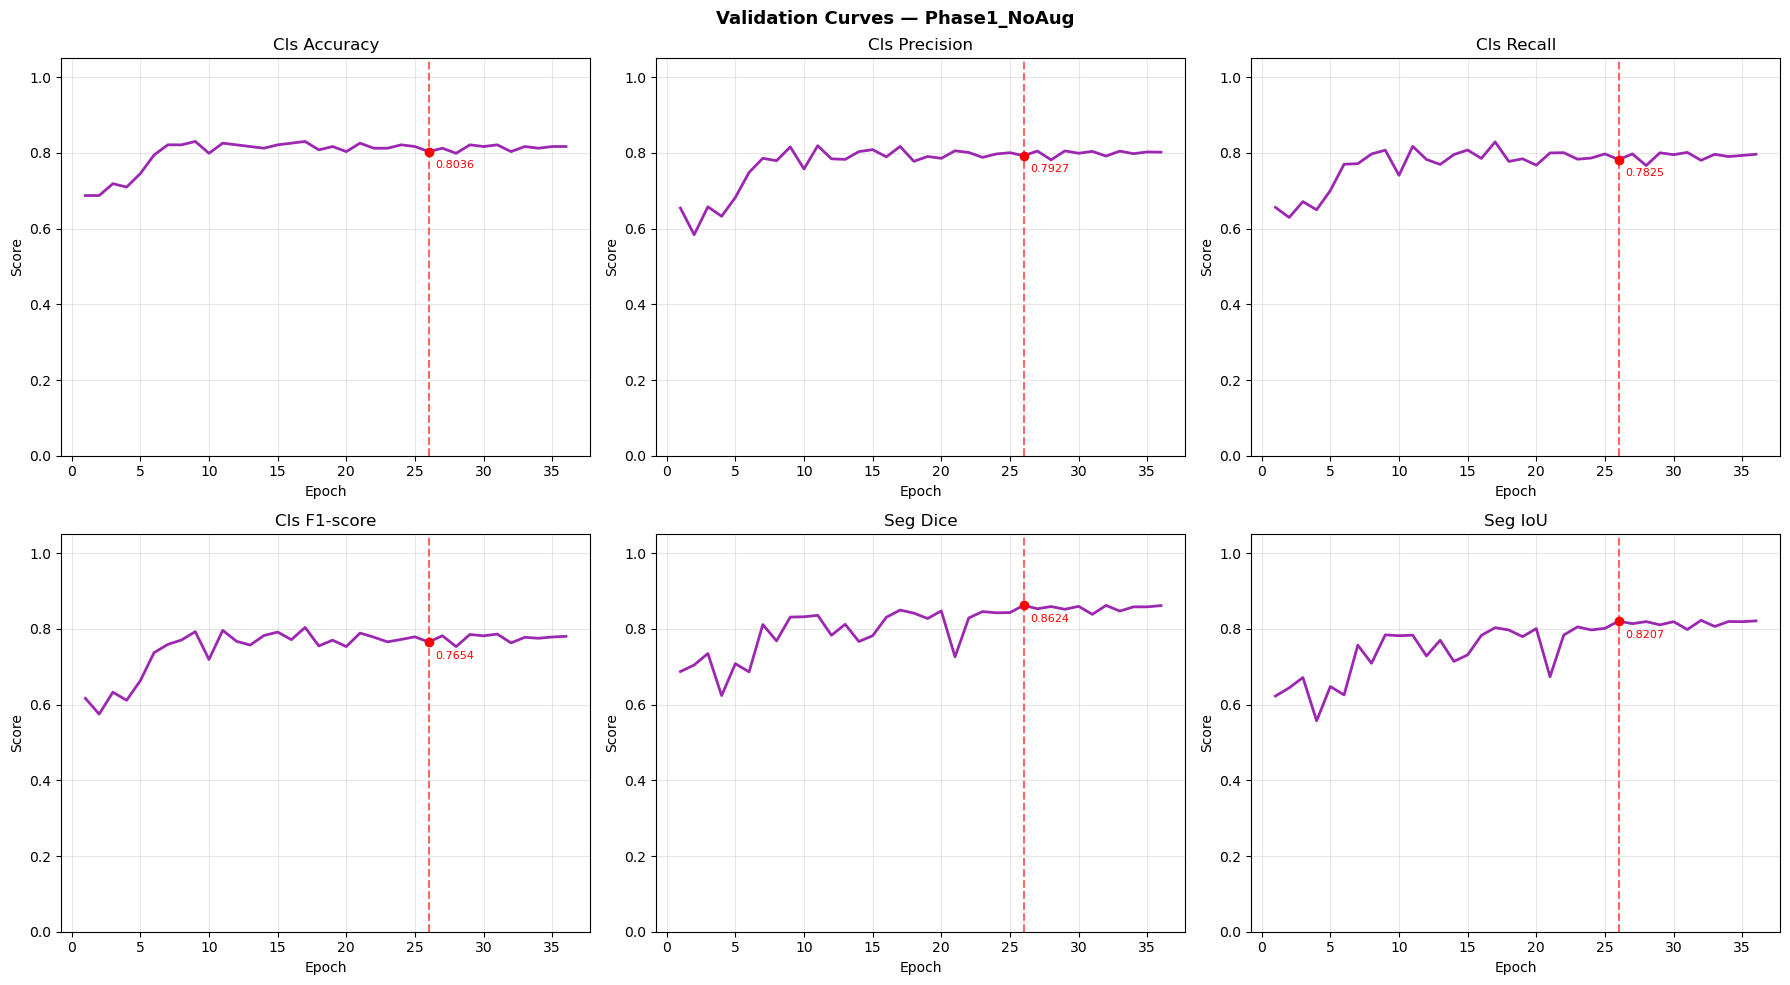

In [22]:
best_p1 = tracker_p1.best_row("valid_dice")

print("\n" + "="*52)
print("  PHASE-01 VALIDATION SUMMARY — No Augmentation")
print(f"  Best Epoch : {int(best_p1['epoch'])}  |  "
      f"Total Epochs : {len(tracker_p1.history)}")
print("="*52)
print("\n── Classification ──────────────────────────────")
print(f"  Accuracy   : {best_p1['valid_acc']:.4f}")
print(f"  Precision  : {best_p1['valid_cls_precision']:.4f}")
print(f"  Recall     : {best_p1['valid_cls_recall']:.4f}")
print(f"  F1-score   : {best_p1['valid_cls_f1']:.4f}")
print("\n── Segmentation ────────────────────────────────")
print(f"  Dice       : {best_p1['valid_dice']:.4f}")
print(f"  IoU        : {best_p1['valid_iou']:.4f}")
print(f"  Precision  : {best_p1['valid_seg_precision']:.4f}")
print(f"  Recall     : {best_p1['valid_seg_recall']:.4f}")
print(f"  F1-score   : {best_p1['valid_seg_f1']:.4f}")
print("="*52)

# Training curves
plot_training_curves(tracker_p1,
                     save_path=PHASE1_DIR / "val_curves_phase1.png")



Phase-01 — Running final TEST evaluation...



  PHASE-01 TEST RESULTS — No Augmentation
  Cls Accuracy    : 0.8190
  Cls Precision   : 0.8121
  Cls Recall      : 0.7815
  Cls F1-score    : 0.7941
  Seg Accuracy    : 0.9819
  Seg Precision   : 0.8294
  Seg Recall      : 0.7810
  Seg F1-score    : 0.8044
  Dice            : 0.4257
  IoU             : 0.3839
Saved → checkpoints_fpn_phase1\cm_phase1.png


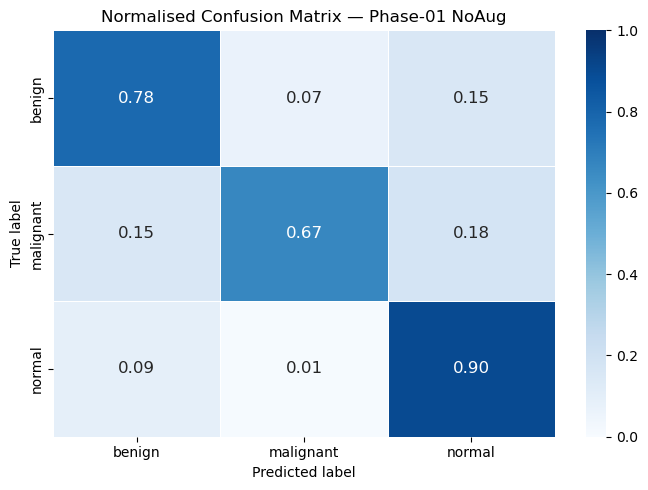

Saved → checkpoints_fpn_phase1\metrics_bar_phase1.png


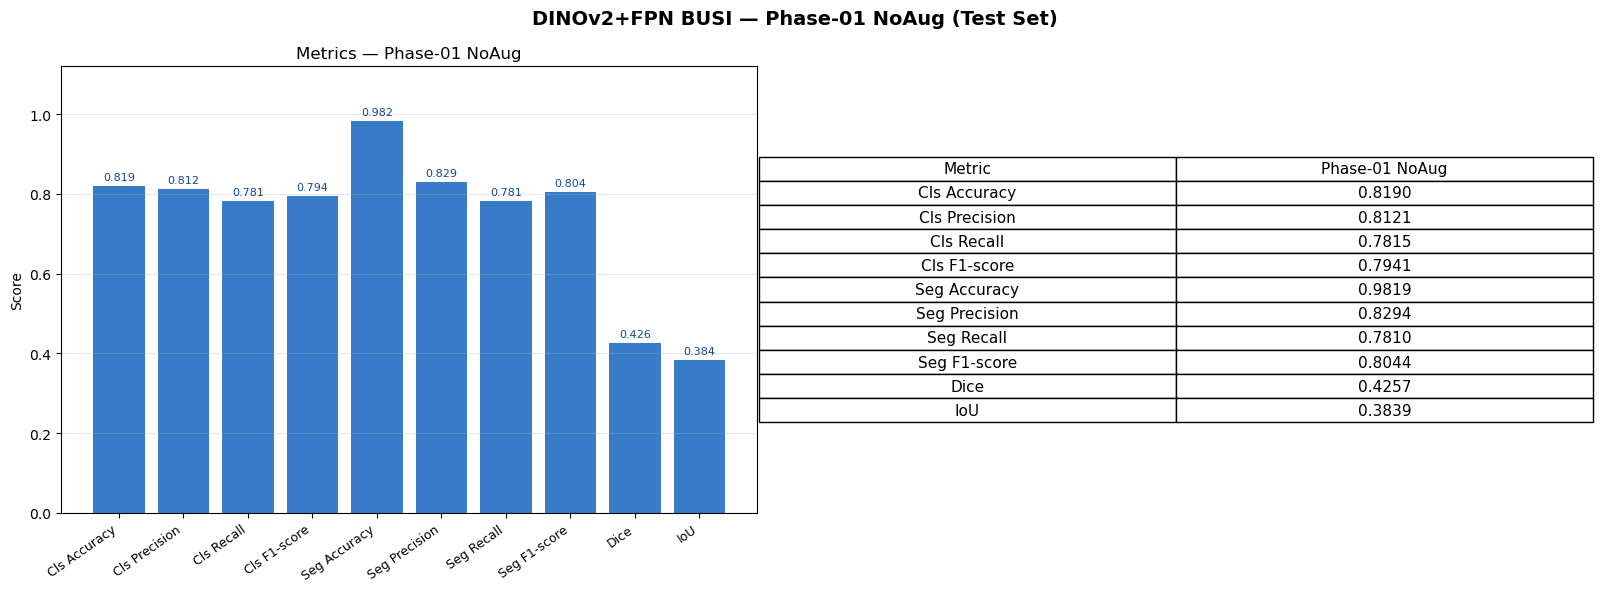

In [23]:
print("\nPhase-01 — Running final TEST evaluation...")
test_metrics_p1, cm_norm_p1 = full_evaluate(model_p1, test_loader_p1,
                                              desc="Test Phase-01")

print("\n" + "="*52)
print("  PHASE-01 TEST RESULTS — No Augmentation")
print("="*52)
for k, v in test_metrics_p1.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*52)

plot_confusion_matrix(cm_norm_p1, "Phase-01 NoAug",
                      save_path=PHASE1_DIR / "cm_phase1.png")
plot_metrics_bar(test_metrics_p1, "Phase-01 NoAug",
                 save_path=PHASE1_DIR / "metrics_bar_phase1.png")



---
## Phase-02 — DINOv2 + FPN · With Strong Augmentation

**Objective:** assess whether strong synchronized augmentations improve the FPN-based model
over Phase-01 (the no-augmentation baseline).

Augmentations applied **only to training** (val/test remain resize-only):
- Horizontal & Vertical Flip
- ShiftScaleRotate · ElasticTransform · GridDistortion
- RandomBrightnessContrast · GaussianBlur · GaussNoise


In [24]:
set_seed(CFG["seed"])

PHASE2_DIR = Path("checkpoints_fpn_phase2")
PHASE2_DIR.mkdir(exist_ok=True)

(train_loader_p2, valid_loader_p2,
 test_loader_p2, _, _) = make_loaders(
    train_tfms=strong_aug_tfms,
    val_tfms=val_tfms,
)
print("Phase-02 DataLoaders ready — strong augmentation on training set")


train=1026  valid=220  test=221
Phase-02 DataLoaders ready — strong augmentation on training set


In [25]:
set_seed(CFG["seed"])

model_p2       = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

optimizer_p2, scheduler_p2 = build_optimizer(model_p2)
scaler_p2   = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
es_p2       = EarlyStopping(patience=CFG["patience"], min_delta=CFG["min_delta"],
                             mode="max")
tracker_p2  = ExperimentTracker(PHASE2_DIR, "Phase2_StrongAug")

best_dice_p2   = 0.0
training_start = time.perf_counter()

print(f"{'='*60}")
print("  PHASE-02 TRAINING — DINOv2 + FPN  |  Strong Augmentation")
print(f"{'='*60}\n")

for epoch in range(1, CFG["epochs"] + 1):
    epoch_start = time.perf_counter()

    if epoch == 1:
        print(f"[Warm-up] Freezing backbone for {CFG['warmup_epochs']} epoch(s)")
        model_p2.freeze_backbone()
    elif epoch == CFG["warmup_epochs"] + 1:
        print("[Warm-up done] Unfreezing backbone — full fine-tune")
        model_p2.unfreeze_backbone()

    t0          = time.perf_counter()
    train_stats = train_one_epoch(model_p2, train_loader_p2,
                                  optimizer_p2, scaler_p2)
    train_time  = time.perf_counter() - t0

    t0          = time.perf_counter()
    valid_stats = evaluate(model_p2, valid_loader_p2, desc="Valid",
                           epoch=epoch, tag="valid", save_dir=PHASE2_DIR)
    valid_time  = time.perf_counter() - t0

    scheduler_p2.step()
    tracker_p2.log(epoch, train_stats, valid_stats, train_time, valid_time)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f"Ep {epoch:03d}/{CFG['epochs']}  "
        f"loss={train_stats['loss']:.4f}  dice={train_stats['dice']:.4f}  "
        f"acc={train_stats['acc']:.4f}  "
        f"|| val_dice={valid_stats['dice']:.4f}  iou={valid_stats['iou']:.4f}  "
        f"cls_f1={valid_stats['cls_f1']:.4f}  acc={valid_stats['acc']:.4f}  "
        f"[{epoch_time/60:.1f}m]"
    )

    if valid_stats["dice"] > best_dice_p2:
        best_dice_p2 = valid_stats["dice"]
        torch.save({
            "epoch":      epoch,
            "phase":      "Phase2_StrongAug",
            "state_dict": model_p2.state_dict(),
            "dice":       best_dice_p2,
            "cfg":        CFG,
            "valid_metrics": {k: v for k, v in valid_stats.items()
                              if k != "confusion_matrix"},
            "valid_confusion_matrix": valid_stats["confusion_matrix"],
        }, PHASE2_DIR / "best_fpn_phase2.pth")
        print(f"  ✓ Checkpoint saved  "
              f"(dice={best_dice_p2:.4f}  "
              f"cls_f1={valid_stats['cls_f1']:.4f}  "
              f"iou={valid_stats['iou']:.4f})")

    if es_p2(valid_stats["dice"], model_p2):
        print(f"\n[EarlyStopping] Triggered at epoch {epoch} "
              f"(patience={CFG['patience']})")
        es_p2.restore_best(model_p2)
        break

total_time_p2 = time.perf_counter() - training_start
print(f"\nPhase-02 training complete — {total_time_p2/60:.2f} min")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  PHASE-02 TRAINING — DINOv2 + FPN  |  Strong Augmentation

[Warm-up] Freezing backbone for 5 epoch(s)



──────────────────────────────────────────────────────
  Valid (epoch 1)
──────────────────────────────────────────────────────
  Loss          : 1.5030  (seg=1.2006  cls=0.7558)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6607
  Precision     : 0.5695
  Recall        : 0.5916
  F1-score      : 0.5468
  ── Segmentation ────────────────────────────────
  Dice          : 0.6823
  IoU           : 0.6221
  Precision     : 0.3830
  Recall        : 0.3634
  F1-score      : 0.3207
──────────────────────────────────────────────────────

Ep 001/50  loss=1.7075  dice=0.3167  acc=0.6047  || val_dice=0.6823  iou=0.6221  cls_f1=0.5468  acc=0.6607  [0.5m]
  ✓ Checkpoint saved  (dice=0.6823  cls_f1=0.5468  iou=0.6221)



──────────────────────────────────────────────────────
  Valid (epoch 2)
──────────────────────────────────────────────────────
  Loss          : 1.4235  (seg=1.1432  cls=0.7007)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6964
  Precision     : 0.5858
  Recall        : 0.6317
  F1-score      : 0.5796
  ── Segmentation ────────────────────────────────
  Dice          : 0.6384
  IoU           : 0.5729
  Precision     : 0.3687
  Recall        : 0.4686
  F1-score      : 0.3884
──────────────────────────────────────────────────────

Ep 002/50  loss=1.5007  dice=0.5499  acc=0.6764  || val_dice=0.6384  iou=0.5729  cls_f1=0.5796  acc=0.6964  [0.5m]



──────────────────────────────────────────────────────
  Valid (epoch 3)
──────────────────────────────────────────────────────
  Loss          : 1.3756  (seg=1.1072  cls=0.6710)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6875
  Precision     : 0.6205
  Recall        : 0.6360
  F1-score      : 0.5971
  ── Segmentation ────────────────────────────────
  Dice          : 0.6062
  IoU           : 0.5388
  Precision     : 0.3155
  Recall        : 0.4983
  F1-score      : 0.3517
──────────────────────────────────────────────────────

Ep 003/50  loss=1.4430  dice=0.5847  acc=0.6870  || val_dice=0.6062  iou=0.5388  cls_f1=0.5971  acc=0.6875  [0.5m]


...


──────────────────────────────────────────────────────
  Valid (epoch 46)
──────────────────────────────────────────────────────
  Loss          : 1.0260  (seg=0.7488  cls=0.6929)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8393
  Precision     : 0.8317
  Recall        : 0.8292
  F1-score      : 0.8092
  ── Segmentation ────────────────────────────────
  Dice          : 0.8728
  IoU           : 0.8303
  Precision     : 0.4473
  Recall        : 0.4650
  F1-score      : 0.4487
──────────────────────────────────────────────────────

Ep 046/50  loss=0.7924  dice=0.8984  acc=0.9419  || val_dice=0.8728  iou=0.8303  cls_f1=0.8092  acc=0.8393  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 47)
──────────────────────────────────────────────────────
  Loss          : 1.0237  (seg=0.7523  cls=0.6785)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8393
  Precision     : 0.8317
  Recall        : 0.8292
  F1-score      : 0.8092
  ── Segmentation ────────────────────────────────
  Dice          : 0.8718
  IoU           : 0.8256
  Precision     : 0.4395
  Recall        : 0.4807
  F1-score      : 0.4522
──────────────────────────────────────────────────────

Ep 047/50  loss=0.8137  dice=0.8785  acc=0.9225  || val_dice=0.8718  iou=0.8256  cls_f1=0.8092  acc=0.8393  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 48)
──────────────────────────────────────────────────────
  Loss          : 1.0201  (seg=0.7489  cls=0.6780)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8482
  Precision     : 0.8387
  Recall        : 0.8371
  F1-score      : 0.8172
  ── Segmentation ────────────────────────────────
  Dice          : 0.8723
  IoU           : 0.8270
  Precision     : 0.4430
  Recall        : 0.4781
  F1-score      : 0.4527
──────────────────────────────────────────────────────

Ep 048/50  loss=0.8095  dice=0.8855  acc=0.9283  || val_dice=0.8723  iou=0.8270  cls_f1=0.8172  acc=0.8482  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 49)
──────────────────────────────────────────────────────
  Loss          : 1.0156  (seg=0.7423  cls=0.6833)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8482
  Precision     : 0.8387
  Recall        : 0.8371
  F1-score      : 0.8172
  ── Segmentation ────────────────────────────────
  Dice          : 0.8753
  IoU           : 0.8319
  Precision     : 0.4520
  Recall        : 0.4690
  F1-score      : 0.4512
──────────────────────────────────────────────────────

Ep 049/50  loss=0.8030  dice=0.8929  acc=0.9322  || val_dice=0.8753  iou=0.8319  cls_f1=0.8172  acc=0.8482  [0.7m]
  ✓ Checkpoint saved  (dice=0.8753  cls_f1=0.8172  iou=0.8319)



──────────────────────────────────────────────────────
  Valid (epoch 50)
──────────────────────────────────────────────────────
  Loss          : 1.0228  (seg=0.7507  cls=0.6804)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8482
  Precision     : 0.8387
  Recall        : 0.8371
  F1-score      : 0.8172
  ── Segmentation ────────────────────────────────
  Dice          : 0.8716
  IoU           : 0.8261
  Precision     : 0.4417
  Recall        : 0.4787
  F1-score      : 0.4520
──────────────────────────────────────────────────────

Ep 050/50  loss=0.7994  dice=0.8857  acc=0.9264  || val_dice=0.8716  iou=0.8261  cls_f1=0.8172  acc=0.8482  [0.7m]

Phase-02 training complete — 34.93 min



  PHASE-02 VALIDATION SUMMARY — Strong Augmentation
  Best Epoch : 49  |  Total Epochs : 50

── Classification ──────────────────────────────
  Accuracy   : 0.8482
  Precision  : 0.8387
  Recall     : 0.8371
  F1-score   : 0.8172

── Segmentation ────────────────────────────────
  Dice       : 0.8753
  IoU        : 0.8319
  Precision  : 0.4520
  Recall     : 0.4690
  F1-score   : 0.4512
Saved → checkpoints_fpn_phase2\val_curves_phase2.png


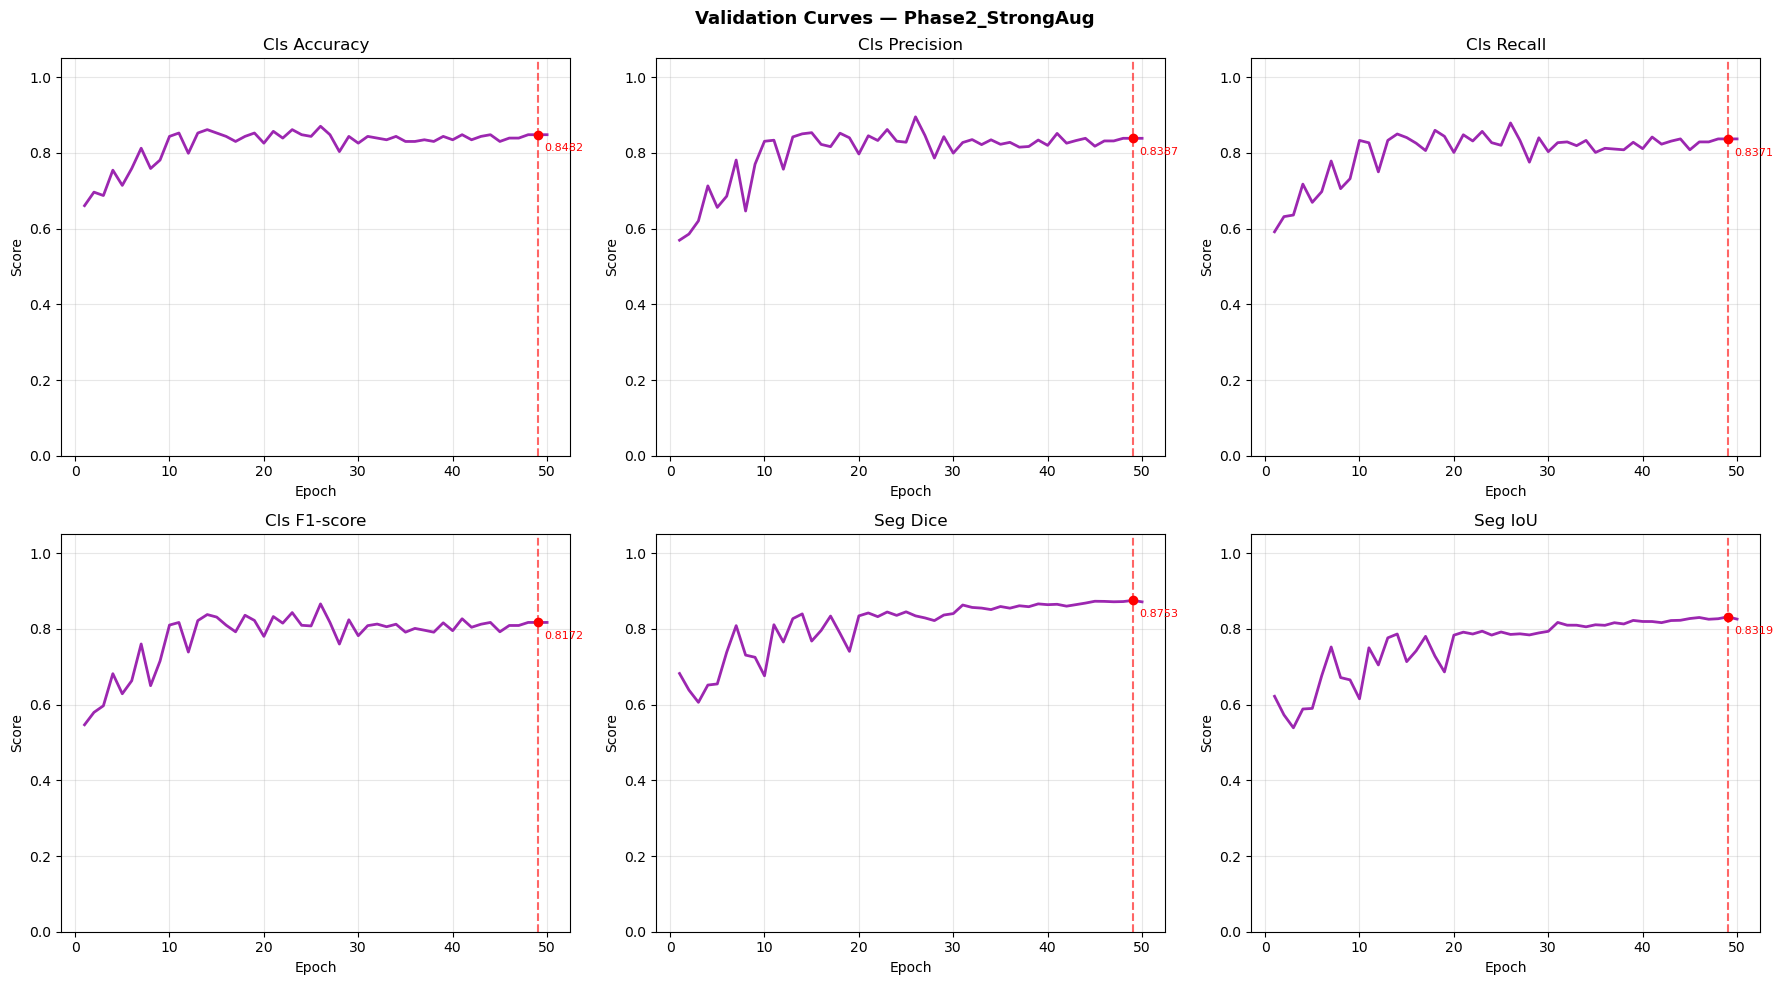

In [26]:
best_p2 = tracker_p2.best_row("valid_dice")

print("\n" + "="*54)
print("  PHASE-02 VALIDATION SUMMARY — Strong Augmentation")
print(f"  Best Epoch : {int(best_p2['epoch'])}  |  "
      f"Total Epochs : {len(tracker_p2.history)}")
print("="*54)
print("\n── Classification ──────────────────────────────")
print(f"  Accuracy   : {best_p2['valid_acc']:.4f}")
print(f"  Precision  : {best_p2['valid_cls_precision']:.4f}")
print(f"  Recall     : {best_p2['valid_cls_recall']:.4f}")
print(f"  F1-score   : {best_p2['valid_cls_f1']:.4f}")
print("\n── Segmentation ────────────────────────────────")
print(f"  Dice       : {best_p2['valid_dice']:.4f}")
print(f"  IoU        : {best_p2['valid_iou']:.4f}")
print(f"  Precision  : {best_p2['valid_seg_precision']:.4f}")
print(f"  Recall     : {best_p2['valid_seg_recall']:.4f}")
print(f"  F1-score   : {best_p2['valid_seg_f1']:.4f}")
print("="*54)

plot_training_curves(tracker_p2,
                     save_path=PHASE2_DIR / "val_curves_phase2.png")



Phase-02 — Running final TEST evaluation...



  PHASE-02 TEST RESULTS — Strong Augmentation
  Cls Accuracy    : 0.8326
  Cls Precision   : 0.8308
  Cls Recall      : 0.8103
  Cls F1-score    : 0.8192
  Seg Accuracy    : 0.9782
  Seg Precision   : 0.7382
  Seg Recall      : 0.8396
  Seg F1-score    : 0.7856
  Dice            : 0.4336
  IoU             : 0.3855
Saved → checkpoints_fpn_phase2\cm_phase2.png


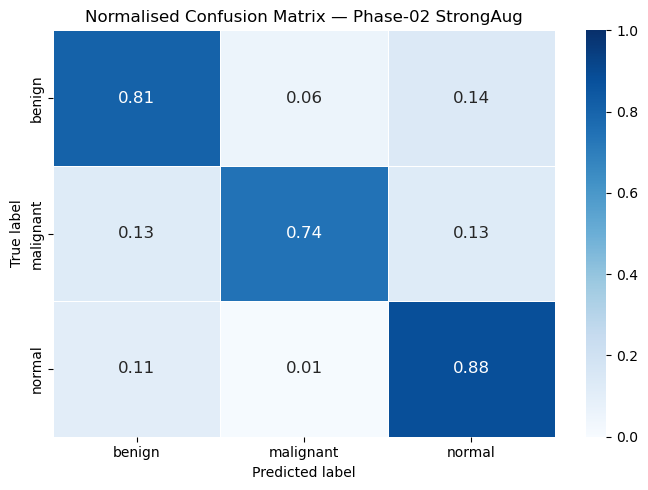

Saved → checkpoints_fpn_phase2\metrics_bar_phase2.png


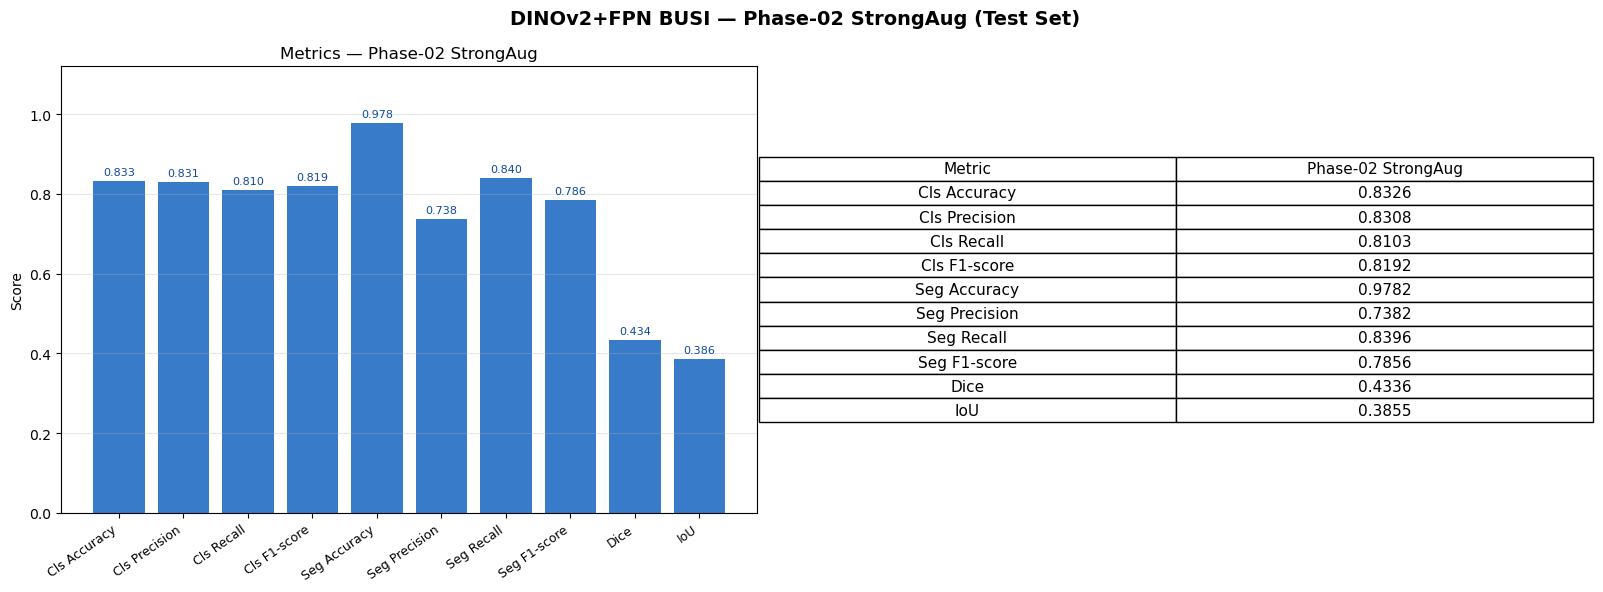

In [27]:
print("\nPhase-02 — Running final TEST evaluation...")
test_metrics_p2, cm_norm_p2 = full_evaluate(model_p2, test_loader_p2,
                                              desc="Test Phase-02")

print("\n" + "="*54)
print("  PHASE-02 TEST RESULTS — Strong Augmentation")
print("="*54)
for k, v in test_metrics_p2.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*54)

plot_confusion_matrix(cm_norm_p2, "Phase-02 StrongAug",
                      save_path=PHASE2_DIR / "cm_phase2.png")
plot_metrics_bar(test_metrics_p2, "Phase-02 StrongAug",
                 save_path=PHASE2_DIR / "metrics_bar_phase2.png")




---
## Cross-Phase Comparison: All 5 Ablation Phases

| Phase | Configuration | Key addition |
|-------|--------------|-------------|
| Phase-01 | DINOv2 + FPN · No Augmentation | Baseline |
| Phase-02 | + Strong Augmentation | Data regularisation |
| Phase-03 | + Focal-Tversky Loss | Loss re-weighting |
| Phase-04 | + Supervised Contrastive (SupCon) | Embedding discriminability |
| Phase-05 | + Test-Time Augmentation (TTA) | Inference robustness |

Each Δ column isolates the contribution of a single added component.
Run this cell **after all five phases** have completed.


In [28]:
# ── 5-Phase grouped bar chart ────────────────────────────────────────────────
metric_keys = list(test_metrics_p1.keys())
p1_vals = [test_metrics_p1[k] for k in metric_keys]
p2_vals = [test_metrics_p2[k] for k in metric_keys]
p3_vals = [test_metrics_p3[k] for k in metric_keys]
p4_vals = [test_metrics_p4[k] for k in metric_keys]
p5_vals = [test_metrics_p5[k] for k in metric_keys]

x     = np.arange(len(metric_keys))
width = 0.15
COLORS = {
    "p1": "#1565C0",   # blue   — baseline
    "p2": "#2E7D32",   # green  — +aug
    "p3": "#E65100",   # orange — +focal-tversky
    "p4": "#6A1B9A",   # purple — +supcon
    "p5": "#B71C1C",   # red    — +TTA
}

fig, ax = plt.subplots(figsize=(24, 7))
fig.suptitle("Ablation Study — DINOv2 + FPN (Test Set)",
             fontsize=14, fontweight="bold")

offsets = [-2, -1, 0, 1, 2]
labels  = ["P1 (FPN, No Aug)",
           "P2 (+Aug)",
           "P3 (+Focal-Tversky)",
           "P4 (+SupCon)",
           "P5 (+TTA)"]
all_vals  = [p1_vals, p2_vals, p3_vals, p4_vals, p5_vals]
color_keys= ["p1", "p2", "p3", "p4", "p5"]

for off, vals, lbl, ck in zip(offsets, all_vals, labels, color_keys):
    bars = ax.bar(x + off * width, vals, width,
                  label=lbl, color=COLORS[ck], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.006,
                f"{h:.3f}", ha="center", va="bottom",
                fontsize=5.5, color=COLORS[ck])

ax.set_xticks(x)
ax.set_xticklabels(metric_keys, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.26)
ax.set_ylabel("Score")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ablation_all_phases.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ablation_all_phases.png")

# ── Printable 5-phase ablation table ─────────────────────────────────────────
d12 = [round(p2_vals[i]-p1_vals[i],4) for i in range(len(metric_keys))]
d23 = [round(p3_vals[i]-p2_vals[i],4) for i in range(len(metric_keys))]
d34 = [round(p4_vals[i]-p3_vals[i],4) for i in range(len(metric_keys))]
d45 = [round(p5_vals[i]-p4_vals[i],4) for i in range(len(metric_keys))]

def arrow(d): return "▲" if d>0 else ("▼" if d<0 else "─")
def fd(d):    return ("+" if d>=0 else "") + f"{d:.4f}"

W = 104
print("\n" + "="*W)
print("  ABLATION TABLE — DINOv2 + FPN  (all metrics on test set)")
print(f"  {'Metric':<16} {'P1':>8} {'P2':>8} {'ΔP1→2':>8}"
      f" {'P3':>8} {'ΔP2→3':>8} {'P4':>8} {'ΔP3→4':>8}"
      f" {'P5':>8} {'ΔP4→5':>8}")
print("="*W)
for m,p1,p2,d1,p3,d2,p4,d3,p5,d4 in zip(
        metric_keys,p1_vals,p2_vals,d12,p3_vals,d23,p4_vals,d34,p5_vals,d45):
    print(f"  {m:<16} {p1:>8.4f} {p2:>8.4f} {arrow(d1)}{abs(d1):>7.4f}"
          f" {p3:>8.4f} {arrow(d2)}{abs(d2):>7.4f}"
          f" {p4:>8.4f} {arrow(d3)}{abs(d3):>7.4f}"
          f" {p5:>8.4f} {arrow(d4)}{abs(d4):>7.4f}")
print("="*W)


NameError: name 'test_metrics_p3' is not defined

---
## Phase-03 — DINOv2 + FPN · Strong Augmentation · +Focal-Tversky Loss

**Objective:** isolate the contribution of the Focal-Tversky segmentation loss over
Phase-02 (which already has strong augmentation and the FPN decoder).

**What changes from Phase-02:**

| Item | Phase-02 | Phase-03 |
|------|----------|----------|
| Segmentation loss | `DiceLoss + BCEWithLogitsLoss` | **`FocalTverskyLoss`** |
| α (FP weight) | — | 0.7 |
| β (FN weight) | — | 0.3 |
| γ (focal exponent) | — | 0.75 |
| Augmentation | Strong | Strong (identical) |
| Backbone | DINOv2 ViT-B/14 | Identical |
| Decoder | FPN | Identical |

**Rationale:** β > α is intentional — in breast ultrasound, failing to detect a lesion
(false negative) is clinically more dangerous than a false alarm (false positive).
The focal exponent γ=0.75 further concentrates the gradient on hard, ambiguous regions.


In [29]:
set_seed(CFG["seed"])

PHASE3_DIR = Path("checkpoints_fpn_phase3")
PHASE3_DIR.mkdir(exist_ok=True)

# Phase-03 builds directly on Phase-02: same strong augmentation, new loss only
(train_loader_p3, valid_loader_p3,
 test_loader_p3, _, _) = make_loaders(
    train_tfms=strong_aug_tfms,    # same as Phase-02
    val_tfms=val_tfms,
)
print("Phase-03 DataLoaders ready — strong aug + Focal-Tversky loss")
print(f"  FT params: α={CFG['ft_alpha']}  β={CFG['ft_beta']}  γ={CFG['ft_gamma']}")


train=1026  valid=220  test=221
Phase-03 DataLoaders ready — strong aug + Focal-Tversky loss
  FT params: α=0.7  β=0.3  γ=0.75


In [30]:
set_seed(CFG["seed"])

model_p3      = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

optimizer_p3, scheduler_p3 = build_optimizer(model_p3)
scaler_p3  = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
es_p3      = EarlyStopping(patience=CFG["patience"], min_delta=CFG["min_delta"],
                            mode="max")
tracker_p3 = ExperimentTracker(PHASE3_DIR, "Phase3_FocalTversky")

best_dice_p3   = 0.0
training_start = time.perf_counter()

print(f"{'='*66}")
print("  PHASE-03 TRAINING — DINOv2 + FPN  |  +Focal-Tversky Loss")
print(f"{'='*66}\n")

for epoch in range(1, CFG["epochs"] + 1):
    epoch_start = time.perf_counter()

    # Backbone warm-up scheduling (identical to Phase-01 / 02)
    if epoch == 1:
        print(f"[Warm-up] Freezing backbone for {CFG['warmup_epochs']} epoch(s)")
        model_p3.freeze_backbone()
    elif epoch == CFG["warmup_epochs"] + 1:
        print("[Warm-up done] Unfreezing backbone — full fine-tune")
        model_p3.unfreeze_backbone()

    # ── Train with Focal-Tversky loss ─────────────────────────────────────────
    t0          = time.perf_counter()
    train_stats = train_one_epoch(model_p3, train_loader_p3,
                                  optimizer_p3, scaler_p3,
                                  loss_fn=compute_combined_loss_ft)   # ← Phase-03
    train_time  = time.perf_counter() - t0

    # ── Validate with Focal-Tversky loss ──────────────────────────────────────
    t0          = time.perf_counter()
    valid_stats = evaluate(model_p3, valid_loader_p3, desc="Valid",
                           epoch=epoch, tag="valid", save_dir=PHASE3_DIR,
                           loss_fn=compute_combined_loss_ft)           # ← Phase-03
    valid_time  = time.perf_counter() - t0

    scheduler_p3.step()
    tracker_p3.log(epoch, train_stats, valid_stats, train_time, valid_time)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f"Ep {epoch:03d}/{CFG['epochs']}  "
        f"loss={train_stats['loss']:.4f}  dice={train_stats['dice']:.4f}  "
        f"acc={train_stats['acc']:.4f}  "
        f"|| val_dice={valid_stats['dice']:.4f}  iou={valid_stats['iou']:.4f}  "
        f"cls_f1={valid_stats['cls_f1']:.4f}  acc={valid_stats['acc']:.4f}  "
        f"[{epoch_time/60:.1f}m]"
    )

    # Save best checkpoint
    if valid_stats["dice"] > best_dice_p3:
        best_dice_p3 = valid_stats["dice"]
        torch.save({
            "epoch":      epoch,
            "phase":      "Phase3_FocalTversky",
            "state_dict": model_p3.state_dict(),
            "dice":       best_dice_p3,
            "cfg":        CFG,
            "ft_params":  {"alpha": CFG["ft_alpha"],
                           "beta":  CFG["ft_beta"],
                           "gamma": CFG["ft_gamma"]},
            "valid_metrics": {k: v for k, v in valid_stats.items()
                              if k != "confusion_matrix"},
            "valid_confusion_matrix": valid_stats["confusion_matrix"],
        }, PHASE3_DIR / "best_fpn_phase3.pth")
        print(f"  ✓ Checkpoint saved  "
              f"(dice={best_dice_p3:.4f}  "
              f"cls_f1={valid_stats['cls_f1']:.4f}  "
              f"iou={valid_stats['iou']:.4f})")

    # Early stopping
    if es_p3(valid_stats["dice"], model_p3):
        print(f"\n[EarlyStopping] Triggered at epoch {epoch} "
              f"(patience={CFG['patience']})")
        es_p3.restore_best(model_p3)
        break

total_time_p3 = time.perf_counter() - training_start
print(f"\nPhase-03 training complete — {total_time_p3/60:.2f} min")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  PHASE-03 TRAINING — DINOv2 + FPN  |  +Focal-Tversky Loss

[Warm-up] Freezing backbone for 5 epoch(s)



──────────────────────────────────────────────────────
  Valid (epoch 1)
──────────────────────────────────────────────────────
  Loss          : 1.1875  (seg=0.8879  cls=0.7490)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6562
  Precision     : 0.5689
  Recall        : 0.5950
  F1-score      : 0.5481
  ── Segmentation ────────────────────────────────
  Dice          : 0.2596
  IoU           : 0.1988
  Precision     : 0.2216
  Recall        : 0.5211
  F1-score      : 0.2596
──────────────────────────────────────────────────────

Ep 001/50  loss=1.2736  dice=0.2045  acc=0.6037  || val_dice=0.2596  iou=0.1988  cls_f1=0.5481  acc=0.6562  [0.5m]
  ✓ Checkpoint saved  (dice=0.2596  cls_f1=0.5481  iou=0.1988)



──────────────────────────────────────────────────────
  Valid (epoch 2)
──────────────────────────────────────────────────────
  Loss          : 1.1051  (seg=0.8182  cls=0.7174)
  ── Classification ──────────────────────────────
  Accuracy      : 0.6875
  Precision     : 0.5811
  Recall        : 0.6188
  F1-score      : 0.5671
  ── Segmentation ────────────────────────────────
  Dice          : 0.3649
  IoU           : 0.2957
  Precision     : 0.3779
  Recall        : 0.4143
  F1-score      : 0.3560
──────────────────────────────────────────────────────

Ep 002/50  loss=1.1805  dice=0.2895  acc=0.6802  || val_dice=0.3649  iou=0.2957  cls_f1=0.5671  acc=0.6875  [0.5m]
  ✓ Checkpoint saved  (dice=0.3649  cls_f1=0.5671  iou=0.2957)



──────────────────────────────────────────────────────
  Valid (epoch 3)
──────────────────────────────────────────────────────
  Loss          : 1.1025  (seg=0.8396  cls=0.6573)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7054
  Precision     : 0.6469
  Recall        : 0.6724
  F1-score      : 0.6285
  ── Segmentation ────────────────────────────────
  Dice          : 0.4417
  IoU           : 0.3764
  Precision     : 0.3393
  Recall        : 0.4951
  F1-score      : 0.3703
──────────────────────────────────────────────────────

Ep 003/50  loss=1.1436  dice=0.3388  acc=0.6764  || val_dice=0.4417  iou=0.3764  cls_f1=0.6285  acc=0.7054  [0.5m]
  ✓ Checkpoint saved  (dice=0.4417  cls_f1=0.6285  iou=0.3764)


...


──────────────────────────────────────────────────────
  Valid (epoch 9)
──────────────────────────────────────────────────────
  Loss          : 0.9602  (seg=0.7519  cls=0.5207)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8214
  Precision     : 0.7694
  Recall        : 0.7830
  F1-score      : 0.7536
  ── Segmentation ────────────────────────────────
  Dice          : 0.4015
  IoU           : 0.3440
  Precision     : 0.3914
  Recall        : 0.4939
  F1-score      : 0.4015
──────────────────────────────────────────────────────

Ep 009/50  loss=1.0370  dice=0.3607  acc=0.7791  || val_dice=0.4015  iou=0.3440  cls_f1=0.7536  acc=0.8214  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 10)
──────────────────────────────────────────────────────
  Loss          : 1.0020  (seg=0.7301  cls=0.6796)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7545
  Precision     : 0.7883
  Recall        : 0.7739
  F1-score      : 0.7347
  ── Segmentation ────────────────────────────────
  Dice          : 0.4213
  IoU           : 0.3656
  Precision     : 0.4144
  Recall        : 0.4860
  F1-score      : 0.4213
──────────────────────────────────────────────────────

Ep 010/50  loss=1.0323  dice=0.3726  acc=0.7713  || val_dice=0.4213  iou=0.3656  cls_f1=0.7347  acc=0.7545  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 11)
──────────────────────────────────────────────────────
  Loss          : 0.9152  (seg=0.7434  cls=0.4296)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8214
  Precision     : 0.7989
  Recall        : 0.7931
  F1-score      : 0.7793
  ── Segmentation ────────────────────────────────
  Dice          : 0.4118
  IoU           : 0.3540
  Precision     : 0.4017
  Recall        : 0.4894
  F1-score      : 0.4118
──────────────────────────────────────────────────────

Ep 011/50  loss=0.9963  dice=0.3835  acc=0.8052  || val_dice=0.4118  iou=0.3540  cls_f1=0.7793  acc=0.8214  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 12)
──────────────────────────────────────────────────────
  Loss          : 0.9671  (seg=0.7654  cls=0.5043)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8036
  Precision     : 0.7817
  Recall        : 0.7797
  F1-score      : 0.7617
  ── Segmentation ────────────────────────────────
  Dice          : 0.3918
  IoU           : 0.3335
  Precision     : 0.3783
  Recall        : 0.4874
  F1-score      : 0.3918
──────────────────────────────────────────────────────

Ep 012/50  loss=0.9934  dice=0.3846  acc=0.8110  || val_dice=0.3918  iou=0.3335  cls_f1=0.7617  acc=0.8036  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 13)
──────────────────────────────────────────────────────
  Loss          : 0.8971  (seg=0.7292  cls=0.4197)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8393
  Precision     : 0.8323
  Recall        : 0.8287
  F1-score      : 0.8142
  ── Segmentation ────────────────────────────────
  Dice          : 0.4231
  IoU           : 0.3639
  Precision     : 0.4163
  Recall        : 0.4877
  F1-score      : 0.4231
──────────────────────────────────────────────────────

Ep 013/50  loss=0.9831  dice=0.3772  acc=0.8140  || val_dice=0.4231  iou=0.3639  cls_f1=0.8142  acc=0.8393  [0.7m]

[EarlyStopping] Triggered at epoch 13 (patience=10)
  [EarlyStopping] Restored best weights  (best metric = 0.4417)

Phase-03 training complete — 8.40 min



  PHASE-03 VALIDATION SUMMARY — +Focal-Tversky Loss
  Best Epoch : 3  |  Total Epochs : 13

── Classification ──────────────────────────────
  Accuracy   : 0.7054
  Precision  : 0.6469
  Recall     : 0.6724
  F1-score   : 0.6285

── Segmentation ────────────────────────────────
  Dice       : 0.4417
  IoU        : 0.3764
  Precision  : 0.3393
  Recall     : 0.4951
  F1-score   : 0.3703
Saved → checkpoints_fpn_phase3\val_curves_phase3.png


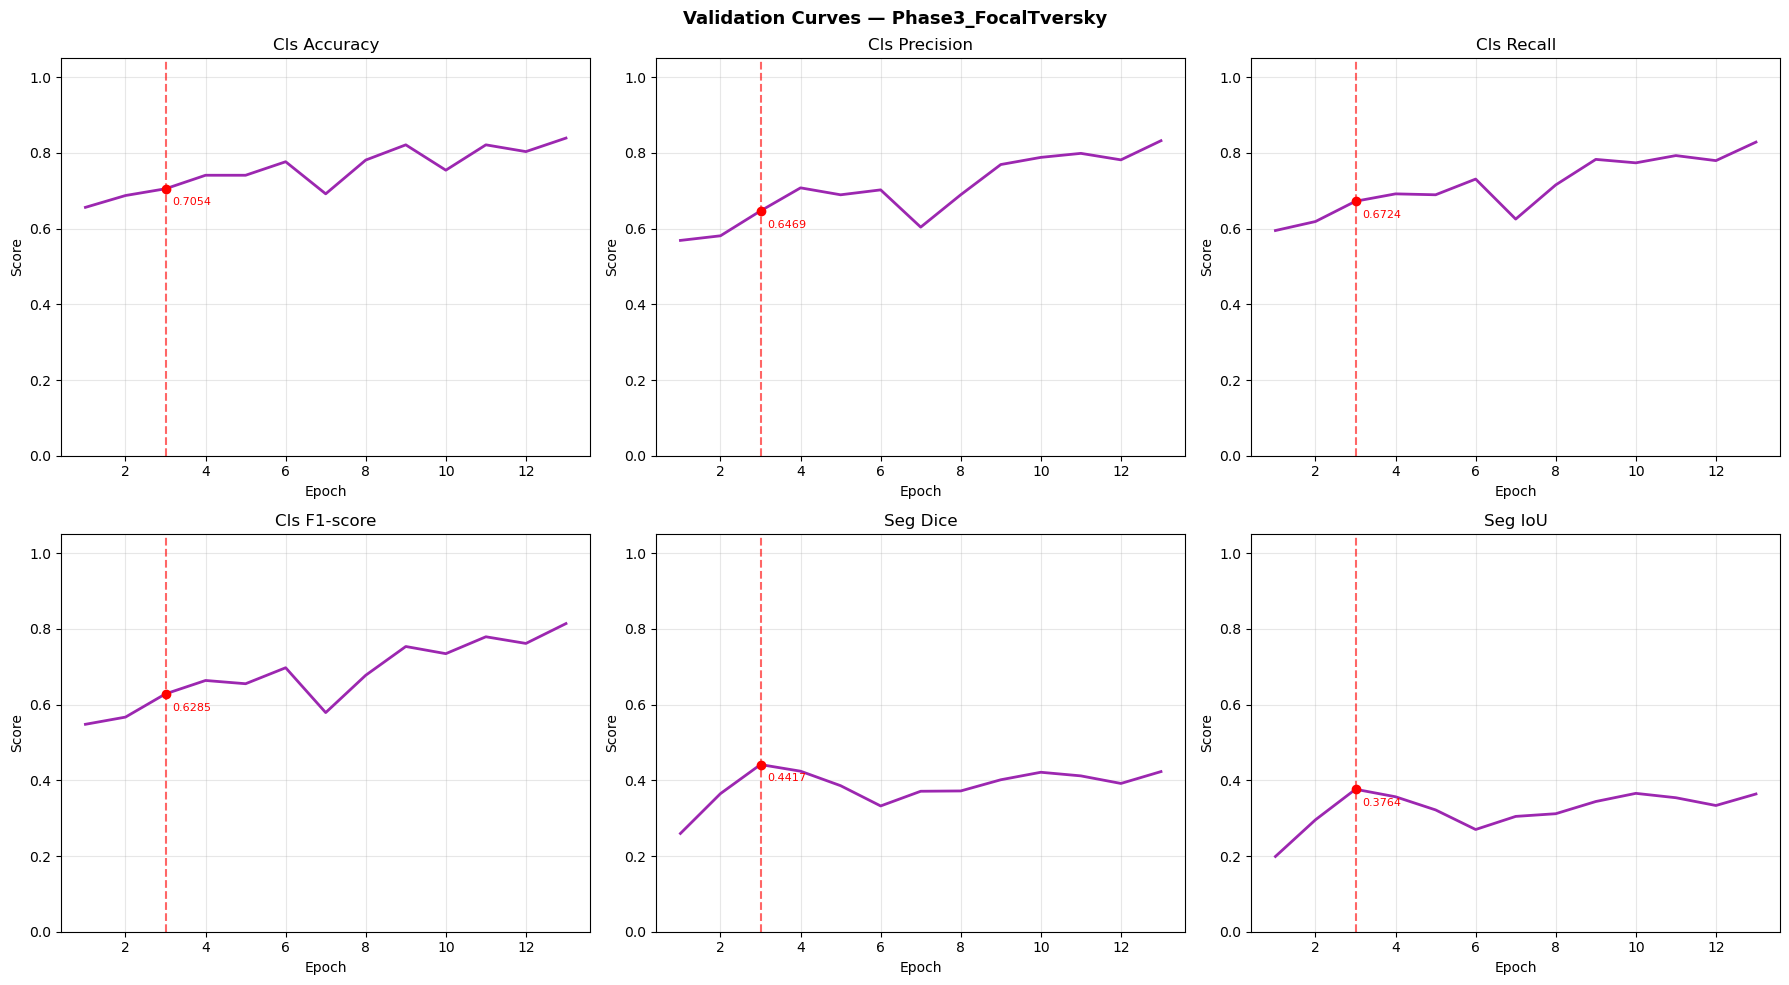

In [31]:
best_p3 = tracker_p3.best_row("valid_dice")

print("\n" + "="*58)
print("  PHASE-03 VALIDATION SUMMARY — +Focal-Tversky Loss")
print(f"  Best Epoch : {int(best_p3['epoch'])}  |  "
      f"Total Epochs : {len(tracker_p3.history)}")
print("="*58)
print("\n── Classification ──────────────────────────────")
print(f"  Accuracy   : {best_p3['valid_acc']:.4f}")
print(f"  Precision  : {best_p3['valid_cls_precision']:.4f}")
print(f"  Recall     : {best_p3['valid_cls_recall']:.4f}")
print(f"  F1-score   : {best_p3['valid_cls_f1']:.4f}")
print("\n── Segmentation ────────────────────────────────")
print(f"  Dice       : {best_p3['valid_dice']:.4f}")
print(f"  IoU        : {best_p3['valid_iou']:.4f}")
print(f"  Precision  : {best_p3['valid_seg_precision']:.4f}")
print(f"  Recall     : {best_p3['valid_seg_recall']:.4f}")
print(f"  F1-score   : {best_p3['valid_seg_f1']:.4f}")
print("="*58)

plot_training_curves(tracker_p3,
                     save_path=PHASE3_DIR / "val_curves_phase3.png")



Phase-03 — Running final TEST evaluation...



  PHASE-03 TEST RESULTS — +Focal-Tversky Loss
  Cls Accuracy    : 0.7059
  Cls Precision   : 0.6653
  Cls Recall      : 0.6070
  Cls F1-score    : 0.6143
  Seg Accuracy    : 0.9443
  Seg Precision   : 0.4526
  Seg Recall      : 0.8084
  Seg F1-score    : 0.5803
  Dice            : 0.3550
  IoU             : 0.2855
Saved → checkpoints_fpn_phase3\cm_phase3.png


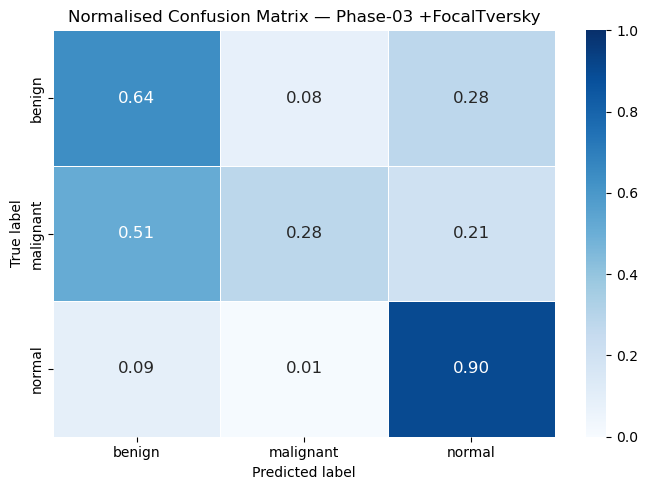

Saved → checkpoints_fpn_phase3\metrics_bar_phase3.png


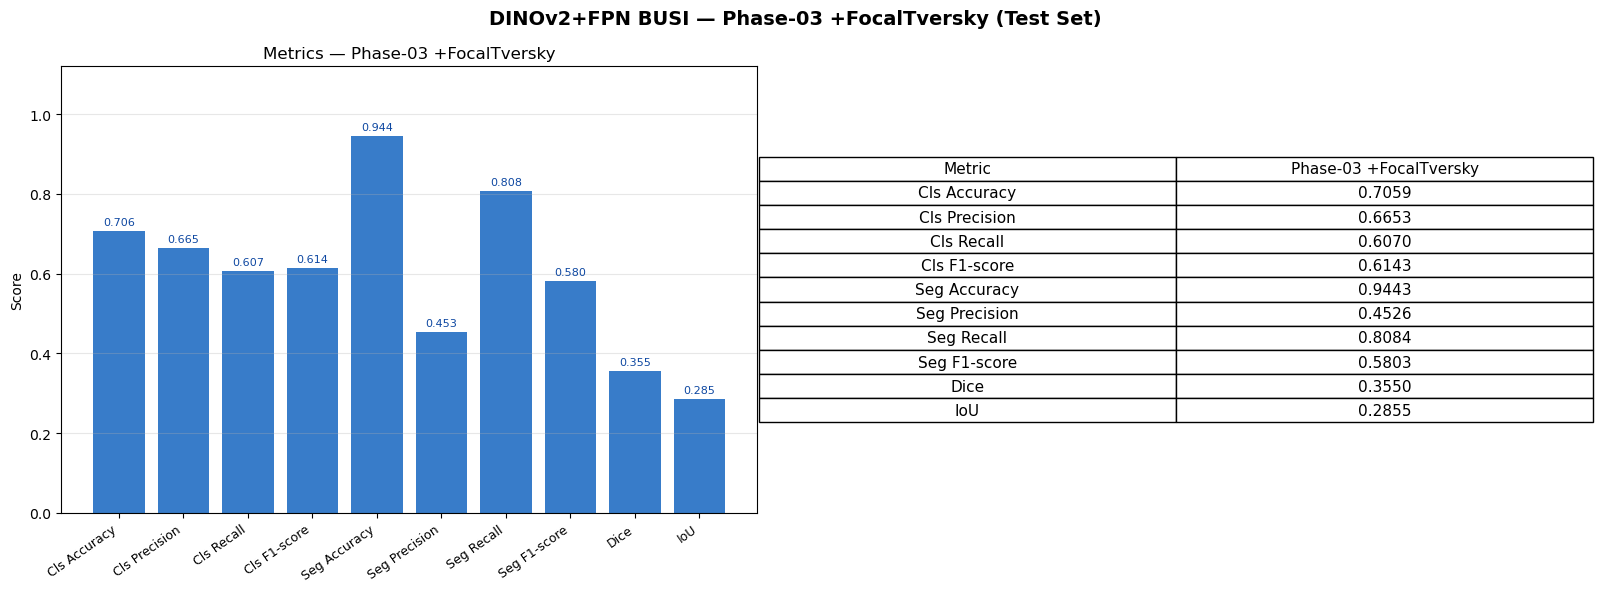

In [33]:
print("\nPhase-03 — Running final TEST evaluation...")
test_metrics_p3, cm_norm_p3 = full_evaluate(model_p3, test_loader_p3,
                                              desc="Test Phase-03")

print("\n" + "="*58)
print("  PHASE-03 TEST RESULTS — +Focal-Tversky Loss")
print("="*58)
for k, v in test_metrics_p3.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*58)

plot_confusion_matrix(cm_norm_p3, "Phase-03 +FocalTversky",
                      save_path=PHASE3_DIR / "cm_phase3.png")
plot_metrics_bar(test_metrics_p3, "Phase-03 +FocalTversky",
                 save_path=PHASE3_DIR / "metrics_bar_phase3.png")



---
## Phase-04 — DINOv2 + FPN · +Focal-Tversky · +Supervised Contrastive (SupCon)

**Objective:** isolate the contribution of Supervised Contrastive Learning on the CLS
token embedding space, on top of Phase-03.

| Item | Phase-03 | Phase-04 |
|------|----------|----------|
| Backbone | DINOv2 ViT-B/14 | Identical |
| Decoder | FPN | Identical |
| Augmentation | Strong | Identical |
| Seg loss | Focal-Tversky | Identical |
| Cls loss | CrossEntropy | Identical |
| **SupCon loss** | — | **SupConLoss on proj_head(CLS token)** |
| Projection head | — | Linear(768→256)→ReLU→Linear→L2-norm |
| SupCon weight | — | 0.1 |
| Temperature τ | — | 0.07 |

**Rationale:** the CLS token feeds directly into the 3-class head. By additionally
pulling same-class tokens together in a normalised projection space, the backbone is
encouraged to produce a tighter, more separable representation — improving
classification F1 and reducing confusion between benign/malignant.


In [34]:
set_seed(CFG["seed"])

PHASE4_DIR = Path("checkpoints_fpn_phase4")
PHASE4_DIR.mkdir(exist_ok=True)

# Phase-04 inherits strong_aug_tfms from Phase-02/03
(train_loader_p4, valid_loader_p4,
 test_loader_p4, _, _) = make_loaders(
    train_tfms=strong_aug_tfms,
    val_tfms=val_tfms,
)

# ── Instantiate projection head ───────────────────────────────────────────────
proj_head_p4 = SupConProjectionHead(
    in_dim     = 768,                      # dinov2-base CLS token dim
    hidden_dim = 256,
    out_dim    = CFG["supcon_proj_dim"],   # 128
).to(device)

print("Phase-04 DataLoaders ready — strong aug + Focal-Tversky + SupCon")
print(f"  SupCon: weight={CFG['supcon_weight']}  τ={CFG['supcon_temp']}  "
      f"proj_dim={CFG['supcon_proj_dim']}")


train=1026  valid=220  test=221
Phase-04 DataLoaders ready — strong aug + Focal-Tversky + SupCon
  SupCon: weight=0.1  τ=0.07  proj_dim=128


In [35]:
set_seed(CFG["seed"])

model_p4 = DINOv2FPNDualTask(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
    fpn_dim=CFG["fpn_dim"],
).to(device)

# Include proj_head params in head param group
optimizer_p4, scheduler_p4 = build_optimizer(model_p4,
                                              extra_modules=[proj_head_p4])
scaler_p4  = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
es_p4      = EarlyStopping(patience=CFG["patience"], min_delta=CFG["min_delta"],
                            mode="max")
tracker_p4 = ExperimentTracker(PHASE4_DIR, "Phase4_SupCon")

best_dice_p4   = 0.0
training_start = time.perf_counter()

print(f"{'='*68}")
print("  PHASE-04 TRAINING — DINOv2 + FPN  |  +Supervised Contrastive")
print(f"{'='*68}\n")

for epoch in range(1, CFG["epochs"] + 1):
    epoch_start = time.perf_counter()

    # Backbone warm-up (identical schedule to all other phases)
    if epoch == 1:
        print(f"[Warm-up] Freezing backbone for {CFG['warmup_epochs']} epoch(s)")
        model_p4.freeze_backbone()
        proj_head_p4.train()   # proj_head always trains
    elif epoch == CFG["warmup_epochs"] + 1:
        print("[Warm-up done] Unfreezing backbone — full fine-tune")
        model_p4.unfreeze_backbone()

    # ── Train: Focal-Tversky + CE + SupCon ───────────────────────────────────
    t0          = time.perf_counter()
    proj_head_p4.train()
    train_stats = train_one_epoch(
        model_p4, train_loader_p4, optimizer_p4, scaler_p4,
        loss_fn=compute_combined_loss_sc,
        proj_head=proj_head_p4,
    )
    train_time  = time.perf_counter() - t0

    # ── Validate ──────────────────────────────────────────────────────────────
    t0          = time.perf_counter()
    proj_head_p4.eval()
    valid_stats = evaluate(
        model_p4, valid_loader_p4, desc="Valid",
        epoch=epoch, tag="valid", save_dir=PHASE4_DIR,
        loss_fn=compute_combined_loss_sc,
        proj_head=proj_head_p4,
    )
    valid_time  = time.perf_counter() - t0

    scheduler_p4.step()
    tracker_p4.log(epoch, train_stats, valid_stats, train_time, valid_time)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f"Ep {epoch:03d}/{CFG['epochs']}  "
        f"loss={train_stats['loss']:.4f}  dice={train_stats['dice']:.4f}  "
        f"acc={train_stats['acc']:.4f}  "
        f"|| val_dice={valid_stats['dice']:.4f}  iou={valid_stats['iou']:.4f}  "
        f"cls_f1={valid_stats['cls_f1']:.4f}  acc={valid_stats['acc']:.4f}  "
        f"[{epoch_time/60:.1f}m]"
    )

    if valid_stats["dice"] > best_dice_p4:
        best_dice_p4 = valid_stats["dice"]
        torch.save({
            "epoch":       epoch,
            "phase":       "Phase4_SupCon",
            "state_dict":  model_p4.state_dict(),
            "proj_head":   proj_head_p4.state_dict(),
            "dice":        best_dice_p4,
            "cfg":         CFG,
            "valid_metrics": {k: v for k, v in valid_stats.items()
                              if k != "confusion_matrix"},
            "valid_confusion_matrix": valid_stats["confusion_matrix"],
        }, PHASE4_DIR / "best_fpn_phase4.pth")
        print(f"  ✓ Checkpoint saved  "
              f"(dice={best_dice_p4:.4f}  "
              f"cls_f1={valid_stats['cls_f1']:.4f}  "
              f"iou={valid_stats['iou']:.4f})")

    if es_p4(valid_stats["dice"], model_p4):
        print(f"\n[EarlyStopping] Triggered at epoch {epoch} "
              f"(patience={CFG['patience']})")
        es_p4.restore_best(model_p4)
        break

total_time_p4 = time.perf_counter() - training_start
print(f"\nPhase-04 training complete — {total_time_p4/60:.2f} min")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  PHASE-04 TRAINING — DINOv2 + FPN  |  +Supervised Contrastive

[Warm-up] Freezing backbone for 5 epoch(s)



──────────────────────────────────────────────────────
  Valid (epoch 1)
──────────────────────────────────────────────────────
  Loss          : 1.3377  (seg=0.8608  cls=0.7538)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7009
  Precision     : 0.6620
  Recall        : 0.6615
  F1-score      : 0.6284
  ── Segmentation ────────────────────────────────
  Dice          : 0.3180
  IoU           : 0.2514
  Precision     : 0.2950
  Recall        : 0.4702
  F1-score      : 0.3180
──────────────────────────────────────────────────────

Ep 001/50  loss=1.4654  dice=0.2095  acc=0.6008  || val_dice=0.3180  iou=0.2514  cls_f1=0.6284  acc=0.7009  [0.5m]
  ✓ Checkpoint saved  (dice=0.3180  cls_f1=0.6284  iou=0.2514)



──────────────────────────────────────────────────────
  Valid (epoch 2)
──────────────────────────────────────────────────────
  Loss          : 1.2883  (seg=0.8380  cls=0.6998)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7009
  Precision     : 0.6122
  Recall        : 0.6347
  F1-score      : 0.5922
  ── Segmentation ────────────────────────────────
  Dice          : 0.3468
  IoU           : 0.2823
  Precision     : 0.3496
  Recall        : 0.4331
  F1-score      : 0.3379
──────────────────────────────────────────────────────

Ep 002/50  loss=1.3528  dice=0.2940  acc=0.6851  || val_dice=0.3468  iou=0.2823  cls_f1=0.5922  acc=0.7009  [0.5m]
  ✓ Checkpoint saved  (dice=0.3468  cls_f1=0.5922  iou=0.2823)



──────────────────────────────────────────────────────
  Valid (epoch 3)
──────────────────────────────────────────────────────
  Loss          : 1.2694  (seg=0.8318  cls=0.6712)
  ── Classification ──────────────────────────────
  Accuracy      : 0.7009
  Precision     : 0.6566
  Recall        : 0.6687
  F1-score      : 0.6291
  ── Segmentation ────────────────────────────────
  Dice          : 0.4310
  IoU           : 0.3656
  Precision     : 0.3273
  Recall        : 0.4990
  F1-score      : 0.3640
──────────────────────────────────────────────────────

Ep 003/50  loss=1.3167  dice=0.3314  acc=0.7171  || val_dice=0.4310  iou=0.3656  cls_f1=0.6291  acc=0.7009  [0.5m]
  ✓ Checkpoint saved  (dice=0.4310  cls_f1=0.6291  iou=0.3656)


...


──────────────────────────────────────────────────────
  Valid (epoch 13)
──────────────────────────────────────────────────────
  Loss          : 1.1034  (seg=0.7468  cls=0.5038)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8170
  Precision     : 0.7925
  Recall        : 0.7939
  F1-score      : 0.7754
  ── Segmentation ────────────────────────────────
  Dice          : 0.4063
  IoU           : 0.3521
  Precision     : 0.3798
  Recall        : 0.5089
  F1-score      : 0.4019
──────────────────────────────────────────────────────

Ep 013/50  loss=1.1406  dice=0.3744  acc=0.8236  || val_dice=0.4063  iou=0.3521  cls_f1=0.7754  acc=0.8170  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 14)
──────────────────────────────────────────────────────
  Loss          : 1.0856  (seg=0.7477  cls=0.4740)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8438
  Precision     : 0.8520
  Recall        : 0.8376
  F1-score      : 0.8253
  ── Segmentation ────────────────────────────────
  Dice          : 0.4271
  IoU           : 0.3711
  Precision     : 0.4194
  Recall        : 0.4987
  F1-score      : 0.4271
──────────────────────────────────────────────────────

Ep 014/50  loss=1.1214  dice=0.3858  acc=0.8479  || val_dice=0.4271  iou=0.3711  cls_f1=0.8253  acc=0.8438  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 15)
──────────────────────────────────────────────────────
  Loss          : 1.0605  (seg=0.7379  cls=0.4402)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8259
  Precision     : 0.8143
  Recall        : 0.8040
  F1-score      : 0.7878
  ── Segmentation ────────────────────────────────
  Dice          : 0.4098
  IoU           : 0.3548
  Precision     : 0.4024
  Recall        : 0.4932
  F1-score      : 0.4098
──────────────────────────────────────────────────────

Ep 015/50  loss=1.1142  dice=0.3934  acc=0.8362  || val_dice=0.4098  iou=0.3548  cls_f1=0.7878  acc=0.8259  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 16)
──────────────────────────────────────────────────────
  Loss          : 1.1489  (seg=0.7513  cls=0.5994)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8393
  Precision     : 0.8384
  Recall        : 0.8191
  F1-score      : 0.8137
  ── Segmentation ────────────────────────────────
  Dice          : 0.3915
  IoU           : 0.3314
  Precision     : 0.3956
  Recall        : 0.4739
  F1-score      : 0.3915
──────────────────────────────────────────────────────

Ep 016/50  loss=1.0821  dice=0.4092  acc=0.8391  || val_dice=0.3915  iou=0.3314  cls_f1=0.8137  acc=0.8393  [0.7m]



──────────────────────────────────────────────────────
  Valid (epoch 17)
──────────────────────────────────────────────────────
  Loss          : 1.1192  (seg=0.7455  cls=0.5529)
  ── Classification ──────────────────────────────
  Accuracy      : 0.8304
  Precision     : 0.8100
  Recall        : 0.8026
  F1-score      : 0.7915
  ── Segmentation ────────────────────────────────
  Dice          : 0.4320
  IoU           : 0.3745
  Precision     : 0.4130
  Recall        : 0.4893
  F1-score      : 0.4231
──────────────────────────────────────────────────────

Ep 017/50  loss=1.1023  dice=0.4063  acc=0.8401  || val_dice=0.4320  iou=0.3745  cls_f1=0.7915  acc=0.8304  [0.7m]

[EarlyStopping] Triggered at epoch 17 (patience=10)
  [EarlyStopping] Restored best weights  (best metric = 0.4456)

Phase-04 training complete — 11.23 min



  PHASE-04 VALIDATION SUMMARY — +Supervised Contrastive
  Best Epoch : 7  |  Total Epochs : 17

── Classification ──────────────────────────────
  Accuracy   : 0.8036
  Precision  : 0.7756
  Recall     : 0.7596
  F1-score   : 0.7462

── Segmentation ────────────────────────────────
  Dice       : 0.4456
  IoU        : 0.3860
  Precision  : 0.3986
  Recall     : 0.4910
  F1-score   : 0.4144
Saved → checkpoints_fpn_phase4\val_curves_phase4.png


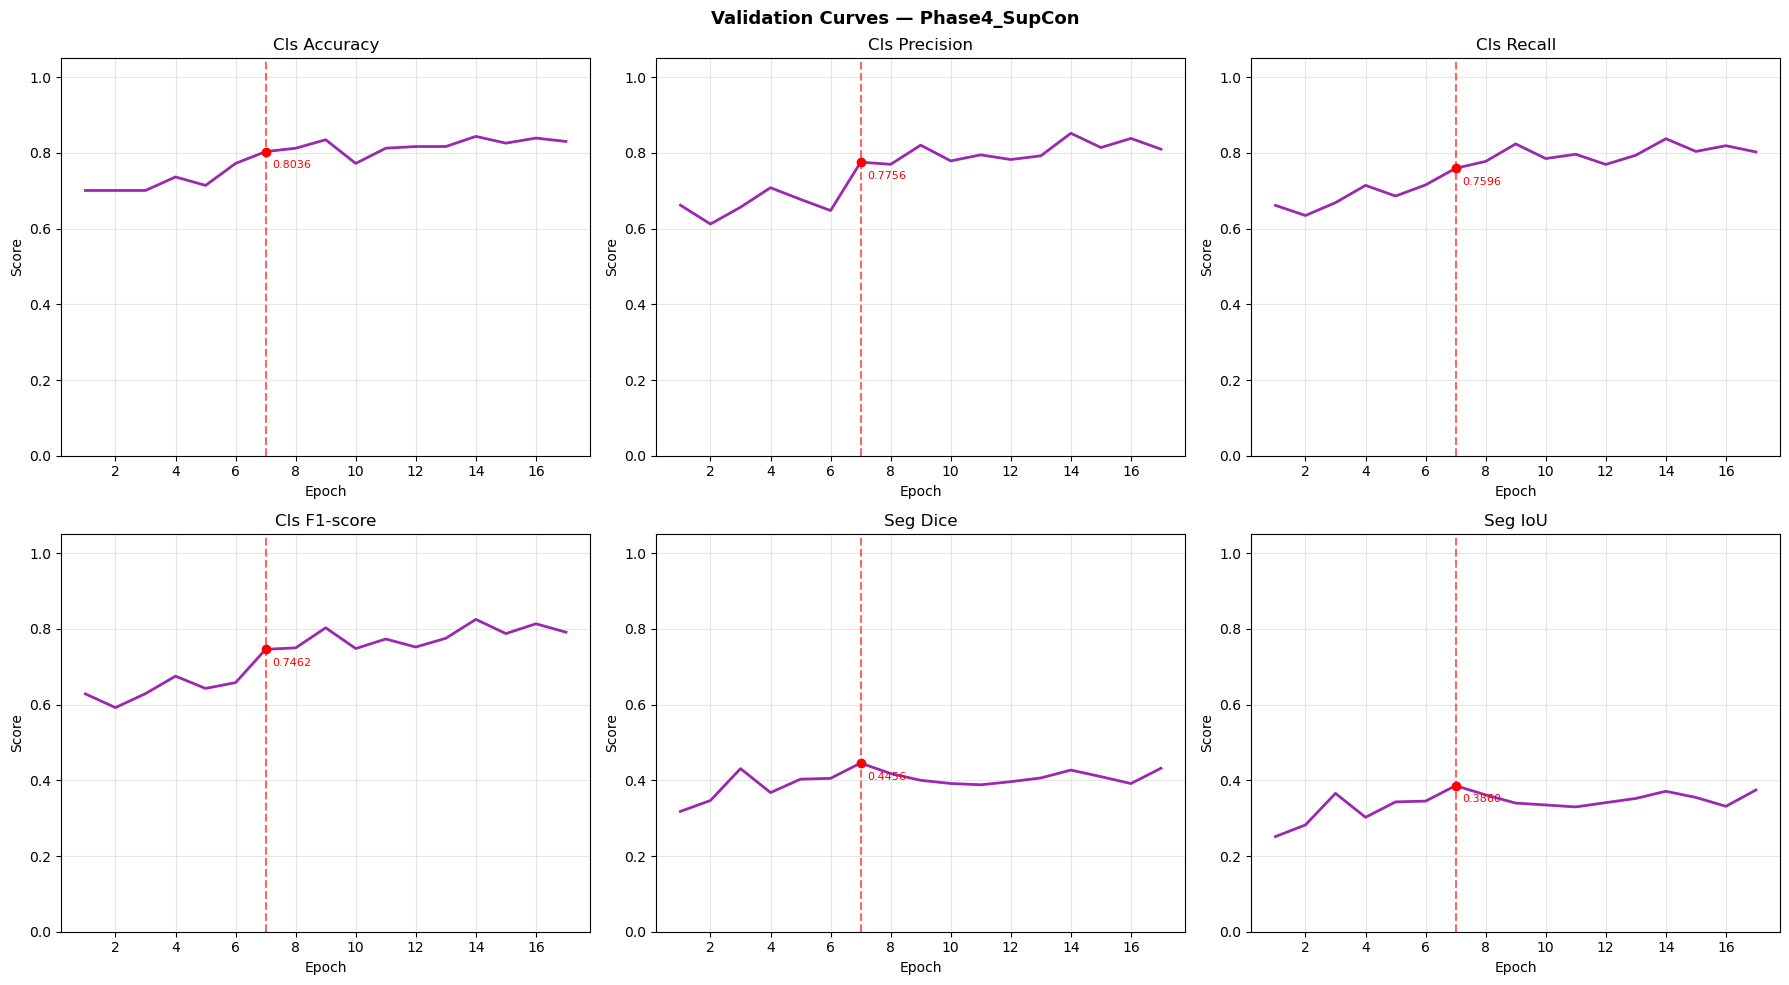

In [36]:
best_p4 = tracker_p4.best_row("valid_dice")

print("\n" + "="*60)
print("  PHASE-04 VALIDATION SUMMARY — +Supervised Contrastive")
print(f"  Best Epoch : {int(best_p4['epoch'])}  |  "
      f"Total Epochs : {len(tracker_p4.history)}")
print("="*60)
print("\n── Classification ──────────────────────────────")
print(f"  Accuracy   : {best_p4['valid_acc']:.4f}")
print(f"  Precision  : {best_p4['valid_cls_precision']:.4f}")
print(f"  Recall     : {best_p4['valid_cls_recall']:.4f}")
print(f"  F1-score   : {best_p4['valid_cls_f1']:.4f}")
print("\n── Segmentation ────────────────────────────────")
print(f"  Dice       : {best_p4['valid_dice']:.4f}")
print(f"  IoU        : {best_p4['valid_iou']:.4f}")
print(f"  Precision  : {best_p4['valid_seg_precision']:.4f}")
print(f"  Recall     : {best_p4['valid_seg_recall']:.4f}")
print(f"  F1-score   : {best_p4['valid_seg_f1']:.4f}")
print("="*60)

plot_training_curves(tracker_p4,
                     save_path=PHASE4_DIR / "val_curves_phase4.png")



Phase-04 — Running final TEST evaluation...



  PHASE-04 TEST RESULTS — +Supervised Contrastive
  Cls Accuracy    : 0.7557
  Cls Precision   : 0.7250
  Cls Recall      : 0.7300
  Cls F1-score    : 0.7088
  Seg Accuracy    : 0.9427
  Seg Precision   : 0.4434
  Seg Recall      : 0.7950
  Seg F1-score    : 0.5693
  Dice            : 0.4056
  IoU             : 0.3427
Saved → checkpoints_fpn_phase4\cm_phase4.png


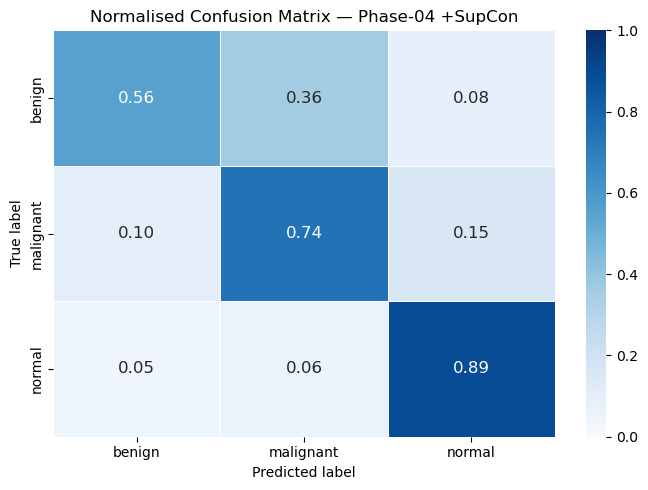

Saved → checkpoints_fpn_phase4\metrics_bar_phase4.png


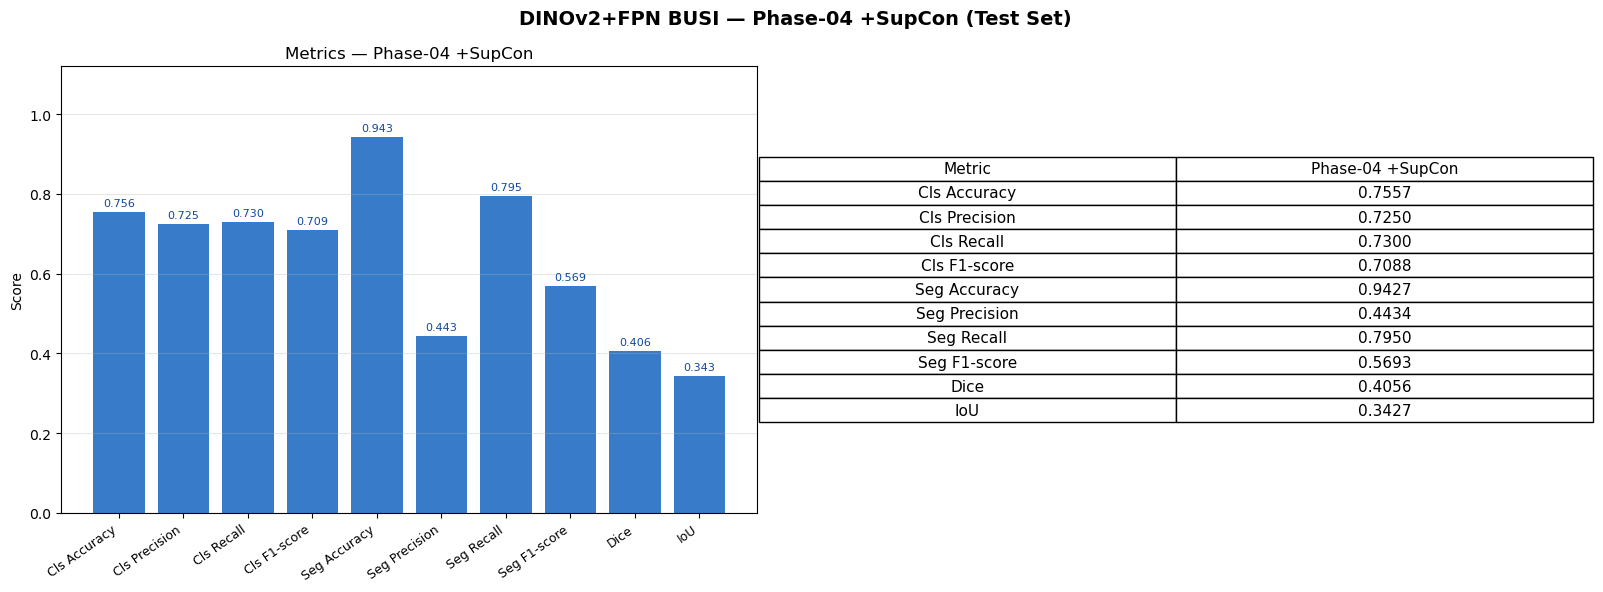

In [38]:
print("\nPhase-04 — Running final TEST evaluation...")
proj_head_p4.eval()
test_metrics_p4, cm_norm_p4 = full_evaluate(model_p4, test_loader_p4,
                                              desc="Test Phase-04")

print("\n" + "="*60)
print("  PHASE-04 TEST RESULTS — +Supervised Contrastive")
print("="*60)
for k, v in test_metrics_p4.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*60)

plot_confusion_matrix(cm_norm_p4, "Phase-04 +SupCon",
                      save_path=PHASE4_DIR / "cm_phase4.png")
plot_metrics_bar(test_metrics_p4, "Phase-04 +SupCon",
                 save_path=PHASE4_DIR / "metrics_bar_phase4.png")




---
## Phase-05 — +Test-Time Augmentation (TTA)

**Objective:** isolate the contribution of TTA on top of the fully trained Phase-04 model.

**No retraining.** Phase-05 takes Phase-04's best checkpoint and runs inference
with 4 augmented variants per image, averaging predictions before thresholding.

| Variant | Transform |
|---------|-----------|
| 0 | Original (no augmentation) |
| 1 | Horizontal flip → predict → un-flip mask |
| 2 | Vertical flip → predict → un-flip mask |
| 3 | H + V flip → predict → un-flip mask |

**Segmentation:** sigmoid probabilities averaged across all 4 variants (after
spatial un-flipping) → threshold at 0.5 → binary mask.  
**Classification:** softmax probabilities averaged → argmax.

This cell loads `model_p4` directly from memory (or reloads from checkpoint
if the kernel was restarted) and calls `full_evaluate_tta`.


Using model_p4 already in GPU memory.

Phase-05 — TTA inference (4 variants per image)...



  PHASE-05 TEST RESULTS — +TTA (4 variants, averaged probs)
  Cls Accuracy    : 0.7466
  Cls Precision   : 0.7247
  Cls Recall      : 0.7327
  Cls F1-score    : 0.7074
  Seg Accuracy    : 0.9316
  Seg Precision   : 0.3952
  Seg Recall      : 0.8231
  Seg F1-score    : 0.5340
  Dice            : 0.4043
  IoU             : 0.3416

── TTA Contribution (Phase-04 → Phase-05) ──────────────
  Cls Accuracy    : 0.7557  →  0.7466  (▼0.0091)
  Cls Precision   : 0.7250  →  0.7247  (▼0.0003)
  Cls Recall      : 0.7300  →  0.7327  (▲0.0027)
  Cls F1-score    : 0.7088  →  0.7074  (▼0.0014)
  Seg Accuracy    : 0.9427  →  0.9316  (▼0.0111)
  Seg Precision   : 0.4434  →  0.3952  (▼0.0482)
  Seg Recall      : 0.7950  →  0.8231  (▲0.0281)
  Seg F1-score    : 0.5693  →  0.5340  (▼0.0353)
  Dice            : 0.4056  →  0.4043  (▼0.0013)
  IoU             : 0.3427  →  0.3416  (▼0.0011)
Saved → checkpoints_fpn_phase4\cm_phase5_tta.png


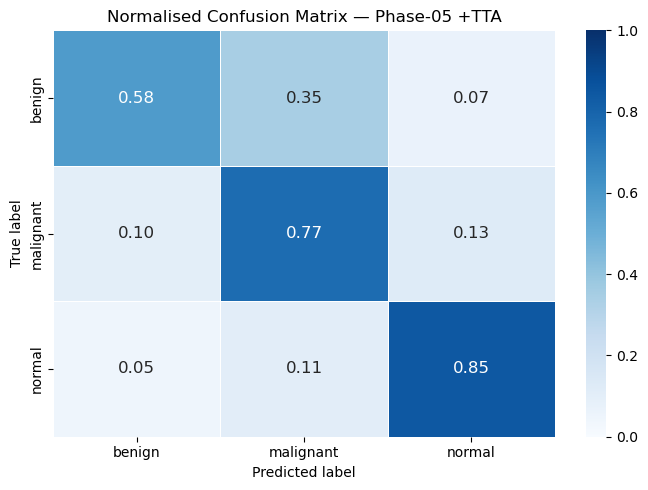

Saved → checkpoints_fpn_phase4\metrics_bar_phase5_tta.png


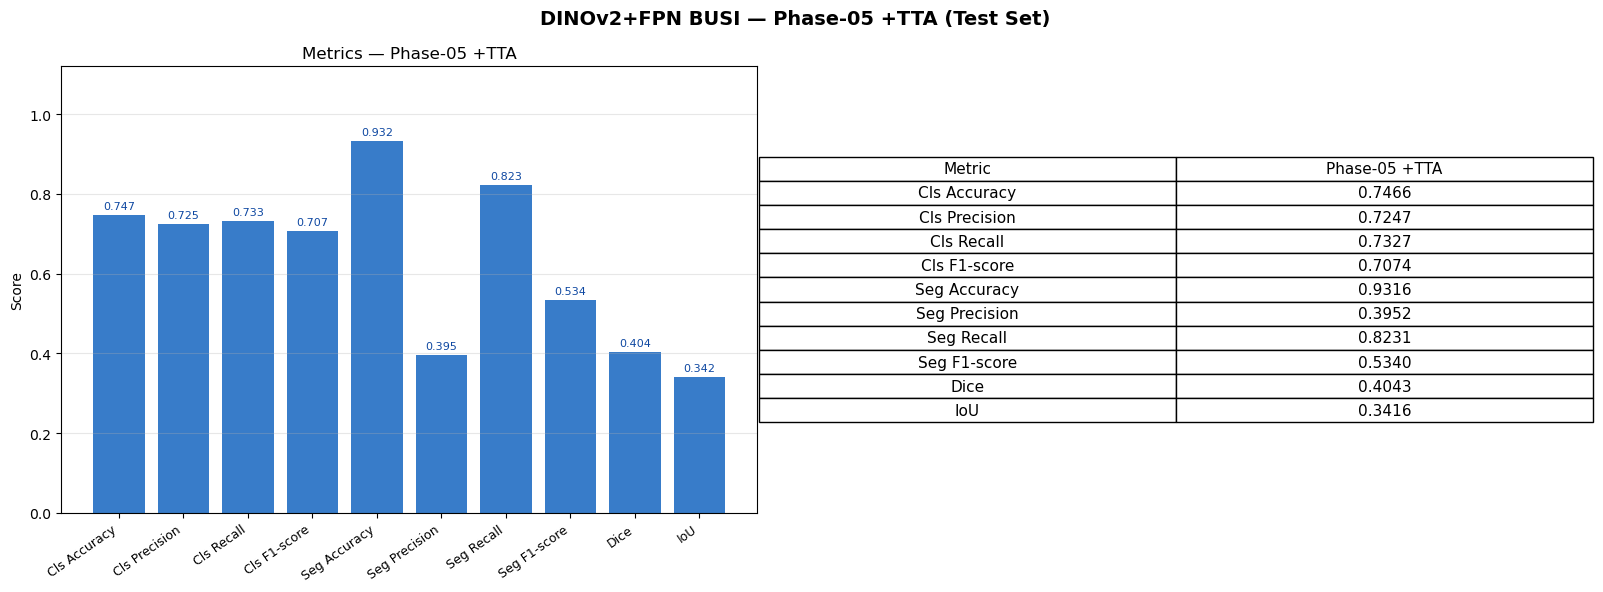

In [40]:
# ── Load Phase-04 model (in-memory or from checkpoint) ───────────────────────
try:
    model_p5_eval = model_p4
    model_p5_eval.eval()
    print("Using model_p4 already in GPU memory.")
except NameError:
    print("model_p4 not found in memory — loading from checkpoint...")
    model_p5_eval = DINOv2FPNDualTask(
        dino_model_name=CFG["dino_model"],
        num_classes=CFG["num_classes"],
        patch_grid=PATCH_GRID,
        img_size=CFG["img_size"],
        fpn_dim=CFG["fpn_dim"],
    ).to(device)
    ckpt = torch.load(
        Path("checkpoints_fpn_phase4") / "best_fpn_phase4.pth",
        map_location=device,
    )
    model_p5_eval.load_state_dict(ckpt["state_dict"])
    model_p5_eval.eval()
    print(f"Checkpoint loaded (epoch={ckpt['epoch']}  dice={ckpt['dice']:.4f})")

# Also need test_loader_p4 — recreate if kernel was restarted
try:
    _ = test_loader_p4
except NameError:
    set_seed(CFG["seed"])
    _, _, test_loader_p4, _, _ = make_loaders(
        train_tfms=strong_aug_tfms, val_tfms=val_tfms)
    print("test_loader_p4 recreated.")

# ── Run TTA evaluation ────────────────────────────────────────────────────────
print(f"\nPhase-05 — TTA inference ({CFG['tta_n_aug']} variants per image)...")
test_metrics_p5, cm_norm_p5 = full_evaluate_tta(
    model_p5_eval, test_loader_p4, desc="Test Phase-05 TTA")

print("\n" + "="*62)
print("  PHASE-05 TEST RESULTS — +TTA (4 variants, averaged probs)")
print("="*62)
for k, v in test_metrics_p5.items():
    print(f"  {k:<16}: {v:.4f}")
print("="*62)

# ── Compare Phase-04 vs Phase-05 (TTA contribution) ──────────────────────────
print("\n── TTA Contribution (Phase-04 → Phase-05) ──────────────")
for k in test_metrics_p5:
    d = round(test_metrics_p5[k] - test_metrics_p4[k], 4)
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {k:<16}: {test_metrics_p4[k]:.4f}  →  "
          f"{test_metrics_p5[k]:.4f}  ({arrow}{abs(d):.4f})")

PHASE5_DIR = Path("checkpoints_fpn_phase4")   # same dir — TTA is eval-only
plot_confusion_matrix(cm_norm_p5, "Phase-05 +TTA",
                      save_path=PHASE5_DIR / "cm_phase5_tta.png")
plot_metrics_bar(test_metrics_p5, "Phase-05 +TTA",
                 save_path=PHASE5_DIR / "metrics_bar_phase5_tta.png")


